In [1]:
import pandas as pd
from pathlib import Path

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import hvplot.pandas
import holoviews as hv
import numpy as np
import datetime
import time
import scipy.constants as cst

ev2kcal = 23.06054819 #eV to kcal/mol

pgf_with_rc_fonts = {
    "font.family": "serif",
}
mpl.rcParams.update(pgf_with_rc_fonts)

In [3]:
import os

In [4]:
# Verify if the 'data' subdirectory exist and if not, create it
#data_dir = Path('data2507')
data_dir = Path('../Data_calculation_747Mol')

In [5]:
#smiles = ['DMAC-TRZ','DMAC-DPS','PSPCz','4CzIPN','Px2BP','CzS2','2TCz-DPS','TDBA-DI']

In [6]:
phase = ['gas', 'toluene']#'

In [7]:
data = pd.read_csv(f'data_result2507.csv')#,index_col=0)

# Ce fichier comporte certaines erreurs, de fait certaine valeurs ont été écrite suivant la
# notation française (0,00003), on doit donc manuellement changer (0.00003)
# on exploite le fait qu'on puisse ouvrir le .csv comme un fichier de tableau

In [8]:
data.T

,0,1,2,3,4,5,6,7,8,9,...,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809
Molecule,4CzTPN,DMAC-DPS,PSPCz,Px2BP,CzS2,2TCz-DPS,TDBA-DI,OPDPO,4TCzBN,5TCzBN,...,CNTPA-CZ,CNTPA-PXZ,BMZ-TZ,TPAPm,CzPm,TCPZ,TrisCz-Trz,PTZ–TAZ,DDMA-TXO2,UGH3
HOMO-LUMO gap,1.657868,3.035097,2.844149,1.450116,2.669494,2.312457,2.073381,1.477592,NaN,NaN,...,2.512847,1.937968,1.885169,1.745246,1.710482,1.505635,1.916445,1.515995,2.34809,3.605933
$\Delta E_r(S_0\to T_1)$,1.935861,1.477668,3.036165,1.918621,2.626045,2.543346,2.513691,1.139197,NaN,NaN,...,2.694154,2.458465,1.759711,2.024036,2.085548,1.150034,2.068806,1.934777,2.586736,3.457757
$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,2.6721,3.2672,3.3994,2.5718,3.4353,3.3889,3.0955,2.4872,NaN,NaN,...,3.0737,2.8514,3.3812,2.7272,3.3287,1.3706,3.4171,2.8255,3.4022,5.1889
$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,2.6594,3.239,3.3763,2.5613,3.4128,3.3679,3.0765,2.4473,NaN,NaN,...,3.0456,2.8204,3.3776,2.6987,3.3062,1.314,3.3947,2.816,3.3705,5.1451
$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,2.962,3.7586,3.8497,2.9126,3.904,3.8537,3.5731,2.8037,NaN,NaN,...,3.7273,3.2423,3.3732,3.369,3.8138,2.0541,3.781,3.0996,3.952,5.2144
$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,2.9169,3.7276,3.7768,2.8801,3.8406,3.8048,3.5033,2.7966,NaN,NaN,...,3.6754,3.2063,3.3718,3.3414,3.7754,1.9389,3.7641,3.0884,3.8875,5.1867
$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,2.145885,1.699915,3.438349,2.172866,2.984333,2.892176,2.901525,1.284162,NaN,NaN,...,3.267046,2.795497,1.755547,2.500359,2.389481,1.723541,2.289121,2.122469,3.004756,3.474749
$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,2.123303,1.700573,3.396317,2.157428,2.955224,2.873281,2.862413,1.301793,NaN,NaN,...,3.251278,2.794843,1.756689,2.506064,2.381519,1.696957,2.293927,2.121934,2.983514,3.485714
$\underset{sTDA}{\Delta E_{ST}}$,0.210024,0.222247,0.402184,0.254245,0.358288,0.348829,0.387834,0.144965,NaN,NaN,...,0.572892,0.337032,-0.004164,0.476322,0.303932,0.573507,0.220315,0.187692,0.41802,0.016993


In [9]:
data

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{t_v}(S_0\to T_1)$,$\underset{sTD-DFT}{t_v}(S_0\to T_1)$,$\underset{sTDA}{k_{nr}}$,$\underset{sTD-DFT}{k_{nr}}$,$\underset{sTDA}{k_{rISC}}$,$\underset{sTD-DFT}{k_{rISC}}$,$\underset{sTDA}{k_{ISC}}$,$\underset{sTD-DFT}{k_{ISC}}$,$\underset{sTDA}{\eta_{TADF}}$,$\underset{sTD-DFT}{\eta_{TADF}}$
0,4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,...,2.910,9.814,4.872179e+07,4.515332e+07,2.963132e+03,7.097598e+03,2.963132e+04,7.097598e+04,6.077672e-05,1.569175e-04
1,DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,...,1.051,1.552,6.305272e+06,5.482775e+06,1.846784e+03,1.800401e+03,1.846784e+04,1.800401e+04,2.919545e-04,3.271922e-04
2,PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,...,0.450,0.650,7.845252e+07,6.682583e+07,1.752310e+00,8.906483e+00,1.752310e+01,8.906483e+01,2.233593e-08,1.332788e-07
3,Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,...,0.790,1.580,1.916192e+07,1.591191e+07,5.356550e+02,9.732481e+02,5.356550e+03,9.732481e+03,2.794554e-05,6.112365e-05
4,CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,...,NaN,1.635,8.922026e+07,8.221542e+07,9.572635e+00,2.951504e+01,9.572635e+01,2.951504e+02,1.072920e-07,3.589949e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,...,3.294,11.993,2.997498e+07,2.441523e+07,2.320176e-03,6.488044e-03,2.320176e-02,6.488044e-02,7.740374e-11,2.657376e-10
1806,TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,...,4.169,16.466,2.149979e+07,2.203007e+07,1.990100e+03,1.652513e+03,1.990100e+04,1.652513e+04,9.246954e-05,7.494985e-05
1807,PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,...,NaN,2.269,1.867350e+07,2.671503e+07,7.029507e+03,7.176446e+03,7.029507e+04,7.176446e+04,3.748905e-04,2.678381e-04
1808,DDMA-TXO2,2.348090,2.586736,3.4022,3.3705,3.9520,3.8875,3.004756,2.983514,0.418020,...,2.327,5.209,1.403977e+07,8.943635e+06,9.496923e-01,2.159833e+00,9.496923e+00,2.159833e+01,6.764298e-08,2.414932e-07


In [10]:
#Repérage des occurences non dupliquées (dans gas et toluene)
data.drop_duplicates(subset='Molecule', keep=False)

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{t_v}(S_0\to T_1)$,$\underset{sTD-DFT}{t_v}(S_0\to T_1)$,$\underset{sTDA}{k_{nr}}$,$\underset{sTD-DFT}{k_{nr}}$,$\underset{sTDA}{k_{rISC}}$,$\underset{sTD-DFT}{k_{rISC}}$,$\underset{sTDA}{k_{ISC}}$,$\underset{sTD-DFT}{k_{ISC}}$,$\underset{sTDA}{\eta_{TADF}}$,$\underset{sTD-DFT}{\eta_{TADF}}$


In [11]:
data.keys()

Index(['Molecule', 'HOMO-LUMO gap', '$\Delta E_r(S_0\to T_1)$',
       '$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$',
       '$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$',
       '$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$',
       '$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$',
       '$\underset{sTDA}{\Delta E_{ST}}$',
       '$\underset{sTD-DFT}{\Delta E_{ST}}$',
       '$\underset{sTDA}{S_{shift}(T_1)}$',
       '$\underset{sTD-DFT}{S_{shift}(T_1)}$',
       '$\underset{sTDA}{S_{shift}(S_1)}$',
       '$\underset{sTD-DFT}{S_{shift}(S_1)}$',
       '$\underset{sTDA}{\lambda_{abs}}$',
       '$\underset{sTD-DFT}{\lambda_{abs}}$',
       '$\underset{sTDA}{\lambda_{PL}}$', '$\underset{sTD-DFT}{\lambda_{PL}}$',
       '$\underset{sTDA}{f_{12}}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$', '$\tau_{sTDA}$',
       '$\tau_{sTD-DFT}$', '$\underset{sTDA}{MOF}$',
      

In [12]:
# On enlève les 13 dernières colones et les deux \tau avant le MOF car non pertinentes pour le moment
data1 = data.drop(columns=[r'$\tau_{sTDA}$',r'$\tau_{sTD-DFT}$',
r'$\underset{sTDA}{t_v}(S_0\to S_1)$',
       r'$\underset{sTD-DFT}{t_v}(S_0\to S_1)$', r'$t_r(S_0\to S_1)$',
       r'$\underset{sTDA}{t_v}(S_0\to T_1)$',
       r'$\underset{sTD-DFT}{t_v}(S_0\to T_1)$', r'$\underset{sTDA}{k_{nr}}$',
       r'$\underset{sTD-DFT}{k_{nr}}$', r'$\underset{sTDA}{k_{rISC}}$',
       r'$\underset{sTD-DFT}{k_{rISC}}$', r'$\underset{sTDA}{k_{ISC}}$',
       r'$\underset{sTD-DFT}{k_{ISC}}$', r'$\underset{sTDA}{\eta_{TADF}}$',
       r'$\underset{sTD-DFT}{\eta_{TADF}}$'])
data1

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{abs}}$,$\underset{sTD-DFT}{\lambda_{abs}}$,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$
0,4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,...,418.582709,425.054676,577.776556,583.921394,0.421518,0.361485,-1.052646,-1.090097,159.193847,158.866718
1,DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,...,329.868032,332.611327,729.355241,729.073213,0.053106,0.045789,-1.891473,-1.899448,399.487209,396.461886
2,PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,...,322.061975,328.278433,360.592260,365.054796,0.188445,0.158698,-0.377575,-0.365290,38.530285,36.776363
3,Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,...,425.682203,430.485742,570.602245,574.685199,0.104442,0.086219,-1.431181,-1.433967,144.920042,144.199457
4,CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,...,317.582475,322.825075,415.450286,419.542501,0.361683,0.318215,-0.570560,-0.584919,97.867810,96.717425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1805,TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,...,603.593780,639.456385,719.357347,730.626623,0.367891,0.266324,-2.255582,-2.330564,115.763566,91.170238
1806,TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,...,327.913775,329.386038,541.623619,540.488965,0.105737,0.108188,-1.245772,-1.248127,213.709844,211.102927
1807,PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,...,400.000640,401.451232,584.150904,584.298136,0.893027,0.836545,-0.559887,-0.615835,184.150264,182.846904
1808,DDMA-TXO2,2.348090,2.586736,3.4022,3.3705,3.9520,3.8875,3.004756,2.983514,0.418020,...,313.725198,318.930414,412.626549,415.564263,0.037223,0.023718,-0.994061,-0.986325,98.901350,96.633849


In [13]:
# On enlève partout où il n'y a pas de valeur numérique (et on reindexe à partir de 0)
Data = data1.dropna(how='any',ignore_index=True)
Data

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{abs}}$,$\underset{sTD-DFT}{\lambda_{abs}}$,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$
0,4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,...,418.582709,425.054676,577.776556,583.921394,0.421518,0.361485,-1.052646,-1.090097,159.193847,158.866718
1,DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,...,329.868032,332.611327,729.355241,729.073213,0.053106,0.045789,-1.891473,-1.899448,399.487209,396.461886
2,PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,...,322.061975,328.278433,360.592260,365.054796,0.188445,0.158698,-0.377575,-0.365290,38.530285,36.776363
3,Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,...,425.682203,430.485742,570.602245,574.685199,0.104442,0.086219,-1.431181,-1.433967,144.920042,144.199457
4,CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,...,317.582475,322.825075,415.450286,419.542501,0.361683,0.318215,-0.570560,-0.584919,97.867810,96.717425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1502,TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,...,603.593780,639.456385,719.357347,730.626623,0.367891,0.266324,-2.255582,-2.330564,115.763566,91.170238
1503,TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,...,327.913775,329.386038,541.623619,540.488965,0.105737,0.108188,-1.245772,-1.248127,213.709844,211.102927
1504,PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,...,400.000640,401.451232,584.150904,584.298136,0.893027,0.836545,-0.559887,-0.615835,184.150264,182.846904
1505,DDMA-TXO2,2.348090,2.586736,3.4022,3.3705,3.9520,3.8875,3.004756,2.983514,0.418020,...,313.725198,318.930414,412.626549,415.564263,0.037223,0.023718,-0.994061,-0.986325,98.901350,96.633849


In [14]:
#Repérage des occurences non dupliquées (dans gas et toluene)
Data.drop_duplicates(subset='Molecule', keep=False)

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{abs}}$,$\underset{sTD-DFT}{\lambda_{abs}}$,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$
184,FAc-Py-Ester,1.566099,0.959572,1.9577,1.8961,2.9365,2.8659,1.439333,1.450365,0.479761,...,422.217601,432.618718,861.400362,854.848433,0.024251,0.088351,-2.695939,-2.642870,439.182761,422.229715
222,Phenanthrenequinone,2.424288,2.308062,3.4466,3.4168,3.8476,3.8042,2.576597,2.569752,0.268535,...,322.237755,325.913986,481.193669,482.475378,0.220189,0.206616,-0.940284,-0.947013,158.955915,156.561392
288,cyanoacrylonitrile,2.107292,1.845537,2.6933,2.6230,3.6976,3.6068,2.533716,2.537736,0.688179,...,335.309927,343.751243,489.337431,488.562202,0.158558,0.691261,-1.884084,-1.355402,154.027505,144.810959
371,pyridine-triazole,2.602863,2.513839,3.9378,3.9042,4.6025,4.5665,2.938175,2.940281,0.424336,...,269.384462,271.508154,421.976914,421.674588,1.632319,1.458850,0.521823,0.346247,152.592453,150.166435
373,tetraphenylbenzene,3.474463,2.828275,4.2001,4.1586,4.5823,4.5604,3.085642,3.101541,0.257367,...,270.571980,271.871324,401.809999,399.750338,0.000089,0.000077,-0.629002,-0.644913,131.238019,127.879015
408,"3,6,11-TriAC-BPQ",1.048337,0.900384,2.4059,2.3721,2.9746,2.9055,1.113214,1.102848,0.212830,...,416.809650,426.722418,1113.749772,1124.218540,1.060909,0.933569,-1.451537,-1.568511,696.940122,697.496123
409,"3,6,12-TriAC-BPQ",1.047884,0.812889,2.1161,2.0757,2.7864,2.6974,1.070381,1.056360,0.257492,...,444.961952,459.643354,1158.317957,1173.692408,0.924903,0.726721,-1.719700,-1.903861,713.356005,714.049054
413,TATC-BP,1.761381,2.149451,3.4011,3.3664,3.5679,3.5424,2.254866,2.261827,0.105415,...,347.499085,350.000560,549.851697,548.159520,0.037410,0.034518,-1.118555,-1.128407,202.352612,198.158960
427,TPTQ,2.001850,1.962120,2.4964,2.4644,3.1039,2.9870,2.439603,2.378207,0.477483,...,399.446498,415.079339,508.214715,521.334853,0.385309,0.284746,-1.330054,-1.369221,108.768217,106.255515
494,phenothiaphosphine,3.028801,2.790294,3.4862,3.4628,4.0684,4.0325,3.256277,3.249354,0.465983,...,304.749283,307.462364,380.754445,381.565730,0.269672,0.293179,-0.606017,-0.575586,76.005161,74.103365


In [15]:
# On ne retient que les molécule présentent dans les deux environnements (gas et toluene)
dataOk = Data[Data.duplicated(subset='Molecule', keep=False)]
dataOk = dataOk.reset_index(drop=True) # On modifie les indexes pour commencer à 0 et remplacer les valeurs omisent
dataOk

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{abs}}$,$\underset{sTD-DFT}{\lambda_{abs}}$,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$
0,4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,...,418.582709,425.054676,577.776556,583.921394,0.421518,0.361485,-1.052646,-1.090097,159.193847,158.866718
1,DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,...,329.868032,332.611327,729.355241,729.073213,0.053106,0.045789,-1.891473,-1.899448,399.487209,396.461886
2,PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,...,322.061975,328.278433,360.592260,365.054796,0.188445,0.158698,-0.377575,-0.365290,38.530285,36.776363
3,Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,...,425.682203,430.485742,570.602245,574.685199,0.104442,0.086219,-1.431181,-1.433967,144.920042,144.199457
4,CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,...,317.582475,322.825075,415.450286,419.542501,0.361683,0.318215,-0.570560,-0.584919,97.867810,96.717425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1489,TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,...,603.593780,639.456385,719.357347,730.626623,0.367891,0.266324,-2.255582,-2.330564,115.763566,91.170238
1490,TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,...,327.913775,329.386038,541.623619,540.488965,0.105737,0.108188,-1.245772,-1.248127,213.709844,211.102927
1491,PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,...,400.000640,401.451232,584.150904,584.298136,0.893027,0.836545,-0.559887,-0.615835,184.150264,182.846904
1492,DDMA-TXO2,2.348090,2.586736,3.4022,3.3705,3.9520,3.8875,3.004756,2.983514,0.418020,...,313.725198,318.930414,412.626549,415.564263,0.037223,0.023718,-0.994061,-0.986325,98.901350,96.633849


In [16]:
dataOk.keys()

Index(['Molecule', 'HOMO-LUMO gap', '$\Delta E_r(S_0\to T_1)$',
       '$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$',
       '$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$',
       '$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$',
       '$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$',
       '$\underset{sTDA}{\Delta E_{ST}}$',
       '$\underset{sTD-DFT}{\Delta E_{ST}}$',
       '$\underset{sTDA}{S_{shift}(T_1)}$',
       '$\underset{sTD-DFT}{S_{shift}(T_1)}$',
       '$\underset{sTDA}{S_{shift}(S_1)}$',
       '$\underset{sTD-DFT}{S_{shift}(S_1)}$',
       '$\underset{sTDA}{\lambda_{abs}}$',
       '$\underset{sTD-DFT}{\lambda_{abs}}$',
       '$\underset{sTDA}{\lambda_{PL}}$', '$\underset{sTD-DFT}{\lambda_{PL}}$',
       '$\underset{sTDA}{f_{12}}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$', '$\underset{sTDA}{MOF}$',
       '$\underset{sTD-DFT}{MOF}$', '$\underset{sT

In [17]:
dataOk.dtypes

Molecule                                         object
HOMO-LUMO gap                                   float64
$\Delta E_r(S_0\to T_1)$                        float64
$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$       float64
$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$    float64
$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$       float64
$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$    float64
$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$       float64
$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$    float64
$\underset{sTDA}{\Delta E_{ST}}$                float64
$\underset{sTD-DFT}{\Delta E_{ST}}$             float64
$\underset{sTDA}{S_{shift}(T_1)}$               float64
$\underset{sTD-DFT}{S_{shift}(T_1)}$            float64
$\underset{sTDA}{S_{shift}(S_1)}$               float64
$\underset{sTD-DFT}{S_{shift}(S_1)}$            float64
$\underset{sTDA}{\lambda_{abs}}$                float64
$\underset{sTD-DFT}{\lambda_{abs}}$             float64
$\underset{sTDA}{\lambda_{PL}}$                 

In [18]:
# On change les object en float64 au cas où
#dataOk = dataOk.astype({r'$\underset{sTDA}{f_{12}}(S_0\to S_1)$':'float64', r'$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$':'float64'})

In [19]:
dataOk.dtypes

Molecule                                         object
HOMO-LUMO gap                                   float64
$\Delta E_r(S_0\to T_1)$                        float64
$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$       float64
$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$    float64
$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$       float64
$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$    float64
$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$       float64
$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$    float64
$\underset{sTDA}{\Delta E_{ST}}$                float64
$\underset{sTD-DFT}{\Delta E_{ST}}$             float64
$\underset{sTDA}{S_{shift}(T_1)}$               float64
$\underset{sTD-DFT}{S_{shift}(T_1)}$            float64
$\underset{sTDA}{S_{shift}(S_1)}$               float64
$\underset{sTD-DFT}{S_{shift}(S_1)}$            float64
$\underset{sTDA}{\lambda_{abs}}$                float64
$\underset{sTD-DFT}{\lambda_{abs}}$             float64
$\underset{sTDA}{\lambda_{PL}}$                 

In [20]:
# Détermination du nombre d'éléments par envionnement (la moitié d'un nombre pair)
taille = np.int16(len(dataOk)/2)
taille

747

In [21]:
Gas = dataOk[:taille] #Gas les premières lignes
Gas = Gas.reset_index(drop=True) # On modifie les indexes pour commencer à 0 et remplacer les valeurs omisent
#Gas.to_csv("Data_Gas_results.csv", index=False)
Gas

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{abs}}$,$\underset{sTD-DFT}{\lambda_{abs}}$,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$
0,4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,...,418.582709,425.054676,577.776556,583.921394,0.421518,0.361485,-1.052646,-1.090097,159.193847,158.866718
1,DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,...,329.868032,332.611327,729.355241,729.073213,0.053106,0.045789,-1.891473,-1.899448,399.487209,396.461886
2,PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,...,322.061975,328.278433,360.592260,365.054796,0.188445,0.158698,-0.377575,-0.365290,38.530285,36.776363
3,Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,...,425.682203,430.485742,570.602245,574.685199,0.104442,0.086219,-1.431181,-1.433967,144.920042,144.199457
4,CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,...,317.582475,322.825075,415.450286,419.542501,0.361683,0.318215,-0.570560,-0.584919,97.867810,96.717425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,TCPZ,1.582985,1.094143,1.4766,1.4204,2.1973,2.0785,1.628173,1.601081,0.534030,...,564.257036,596.508051,761.492963,774.378026,0.414404,0.299687,-2.225483,-2.313109,197.235928,177.869975
743,TrisCz-Trz,1.825862,1.920088,3.3890,3.3690,3.6283,3.6090,2.055667,2.056870,0.135579,...,341.714297,343.541697,603.133777,602.780785,0.076621,0.075436,-1.338870,-1.341259,261.419480,259.239088
744,PTZ–TAZ,1.536949,1.986887,2.8167,2.8070,3.0988,3.0871,2.185880,2.185152,0.198992,...,400.103906,401.620286,567.205075,567.394049,0.860504,0.804944,-0.551601,-0.606433,167.101169,165.773763
745,DDMA-TXO2,2.259827,2.755558,3.4394,3.4088,4.1152,4.0649,3.296992,3.285927,0.541434,...,301.283530,305.011682,376.052478,377.318735,0.108287,0.101671,-0.877588,-0.873140,74.768947,72.307053


In [22]:
Tol = dataOk[taille:] #Toluene les dernières lignes
Tol = Tol.reset_index(drop=True) # On modifie les indexes pour commencer à 0 et remplacer les valeurs omisent
#Tol.to_csv("Data_Tol_results.csv", index=False)
Tol

,Molecule,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{abs}}$,$\underset{sTD-DFT}{\lambda_{abs}}$,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$
0,4CzTPN,1.535756,1.847678,2.5218,2.5077,2.8410,2.7898,2.081551,2.055530,0.233872,...,436.410413,444.419666,595.633853,603.173810,0.445521,0.377304,-1.140673,-1.182869,159.223439,158.754144
1,DMAC-DPS,3.023949,1.739478,3.3175,3.2922,3.7638,3.7357,1.973488,1.973807,0.234010,...,329.412292,331.890137,628.248937,628.147430,0.046389,0.039648,-1.648143,-1.655203,298.836645,296.257293
2,PSPCz,2.725237,3.058784,3.4121,3.3890,3.8626,3.7915,3.462636,3.422066,0.403852,...,320.986378,327.005666,358.063037,362.308051,0.218342,0.184596,-0.326725,-0.319901,37.076658,35.302384
3,Px2BP,1.356840,1.861141,2.6332,2.6231,2.9532,2.9241,2.087317,2.074706,0.226175,...,419.830010,424.008066,593.988493,597.598738,0.098458,0.082413,-1.466576,-1.470011,174.158484,173.590673
4,CzS2,2.634871,2.814959,3.4497,3.4275,3.9163,3.8557,3.195705,3.166633,0.380746,...,316.585038,321.560802,387.971383,391.533156,0.402070,0.351436,-0.363717,-0.385280,71.386345,69.972354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,...,603.593780,639.456385,719.357347,730.626623,0.367891,0.266324,-2.255582,-2.330564,115.763566,91.170238
743,TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,...,327.913775,329.386038,541.623619,540.488965,0.105737,0.108188,-1.245772,-1.248127,213.709844,211.102927
744,PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,...,400.000640,401.451232,584.150904,584.298136,0.893027,0.836545,-0.559887,-0.615835,184.150264,182.846904
745,DDMA-TXO2,2.348090,2.586736,3.4022,3.3705,3.9520,3.8875,3.004756,2.983514,0.418020,...,313.725198,318.930414,412.626549,415.564263,0.037223,0.023718,-0.994061,-0.986325,98.901350,96.633849


In [23]:
# On predns les SMILES dans les deux environnements pour s'assuré qu'ils sont identique
smilesGas = np.array(Gas['Molecule'])

In [24]:
# On a les même SMILES dans les deux tableaux
smiles = np.array(Tol['Molecule']) #(Gas['Molecule'])
smiles

array(['4CzTPN', 'DMAC-DPS', 'PSPCz', 'Px2BP', 'CzS2', '2TCz-DPS',
       'TDBA-DI', 'OPDPO', '2CzTPEPCz', 'TBRb', 'TBPe', '2CzPN',
       '3CzFTFP', 'DDPhCz-DCPP', 'ACRXTN', 'TXO-TPA', 'PCTXO', 'IP-PPI',
       'DMDHNP-DPS', '4NTAZ-PPI', 'TAZ-PPI', 'PTZ-mPYR', 'pCNBCzoCF3',
       'PTZTPE-2', '4CzIPN', 'DMAC-TRZ', 'TCzTrz', 'δ-2CbPN', 'CzDCbTrz',
       'α-2CbPN', 'CN-QP', 'TFM-QP', 'NDN', 'mCP', 'ZDZ', 'ZDN',
       'BTCz3CzTPN', '2BTCz2CzTPN', 'APDC-DTPA', 'BMIM', 'ADO-TPA',
       'DCzTrz', 'BDPCC', 'SpiroAC-TRZ', 'DBT-BZ-DMAC', 'DQP', 'TPA-DCPP',
       '2PXZ-OXD', 'BmPyPhB', 'MPPA', 'ACRFLCN', 'PTZ-DCPP', 'BBA-Pyr',
       'PhICz-Pyr', 'PhCz-Pyr', 'PDA-DP', '9CzFDBFDPO', '9PhCzFDBFDPO',
       '9PhCzFDBFSPO', '9CzFDBFSPO', '9ArFDBFxPO', '12BTCzTPN',
       'oDTBPZ-DPXZ', '3DMAC-BP-CN', '3DMAC-BP-Br', 'TPA-PZCN', '1PXZ-BP',
       'PTZ-DBTO2', 'BACQ', '2Cz-DMAC-TXO', '2Cz-DMAC-TTR',
       '2Cz-DMAC-BTB', 'DMAC-BPP', 'Me-MOC', 'Me-DOC', '3DCPO',
       'TDBA-TPDICz', 'TRZ-pIC', 'S

In [25]:
# Vérification de la conformité des SMILES
smilesGas == smiles

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [27]:
# On déplace les dossiers de molécules ayant aboutis à un résultat dans les deux environnements
#for ph in phase:
#    for smi in smiles:
#        os.system(f"mv {data_dir}/{ph}/{smi} 747Data/{ph}")
#        os.system(f"mv {data_dir}/RDKit/{smi}.xyz 747Data/RDKit")

# Extraction des temps de calcul

In [26]:
import re
from datetime import datetime

In [27]:
def calculate_run_time(filename):
    """
    Read a xTB log text file and calculate the run time between start and end lines.
    
    Searches for lines like:
    * started run on 2025/09/12 at 17:53:15.592
    * finished run on 2025/09/12 at 17:53:22.463
    
    Args:
        filename: Path to the text file
    
    Returns:
        Total run time in seconds
    """
    try:
        with open(filename, 'r') as file:
            content = file.read()
        
        # Search for start time
        start_pattern = r'\*\s*started run on\s+(\d{4}/\d{2}/\d{2})\s+at\s+([\d:.]+)'
        start_match = re.search(start_pattern, content)
        
        # Search for end time
        end_pattern = r'\*\s*finished run on\s+(\d{4}/\d{2}/\d{2})\s+at\s+([\d:.]+)'
        end_match = re.search(end_pattern, content)
        
        if not start_match:
            print("Error: Could not find 'started run' line in the file")
            return None
        
        if not end_match:
            print("Error: Could not find 'finished run' line in the file")
            return None
        
        # Extract date and time
        start_date = start_match.group(1)
        start_time = start_match.group(2)
        end_date = end_match.group(1)
        end_time = end_match.group(2)
        
        # Combine date and time, parse as datetime
        start_datetime_str = f"{start_date} {start_time}"
        end_datetime_str = f"{end_date} {end_time}"
        
        start_datetime = datetime.strptime(start_datetime_str, "%Y/%m/%d %H:%M:%S.%f")
        end_datetime = datetime.strptime(end_datetime_str, "%Y/%m/%d %H:%M:%S.%f")
        
        # Calculate difference in seconds
        time_diff = (end_datetime - start_datetime).total_seconds()
        
        print(f"Start: {start_date} at {start_time}")
        print(f"End:   {end_date} at {end_time}")
        print(f"\nRun time: {time_diff} seconds")
        
        return time_diff
        
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
        return None
    except ValueError as e:
        print(f"Error parsing timestamp: {e}")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [28]:
def parse_crest_runtime(filename):
    """
    Read a text file and convert CREST runtime to seconds.
    
    Searches for a line like:
    CREST runtime (total)               0 d,  0 h,  8 min, 15.024 sec
    
    Args:
        filename: Path to the text file
    
    Returns:
        Total runtime in seconds
    """
    try:
        with open(filename, 'r') as file:
            content = file.read()
        
        # Search for the CREST runtime line
        pattern = r'CREST runtime \(total\)\s+(\d+)\s*d,\s*(\d+)\s*h,\s*(\d+)\s*min,\s*([\d.]+)\s*sec'
        match = re.search(pattern, content)
        
        if not match:
            print("Error: Could not find CREST runtime line in the file")
            return None
        
        # Extract values
        days = int(match.group(1))
        hours = int(match.group(2))
        minutes = int(match.group(3))
        seconds = float(match.group(4))
        
        # Convert to total seconds
        total_seconds = (days * 24 * 3600) + (hours * 3600) + (minutes * 60) + seconds
        
        print(f"Found: {match.group(0)}")
        print(f"\nBreakdown:")
        print(f"  Days: {days}")
        print(f"  Hours: {hours}")
        print(f"  Minutes: {minutes}")
        print(f"  Seconds: {seconds}")
        print(f"\nTotal runtime: {total_seconds} seconds")
        
        return total_seconds
        
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [39]:
def calculate_computation_time(filename):
    """
    Read a stda log text file and calculate the computation time between
    the first line (start time) and last line (end time).
    
    Args:
        filename: Path to the text file
    
    Returns:
        Computation time in seconds
    """
    try:
        with open(filename, 'r') as file:
            lines = file.readlines()
        
        if len(lines) < 2:
            print("Error: File must contain at least 2 lines")
            return None
        
        # Get first and last lines
        first_line = lines[0].strip()
        last_line = lines[-1].strip()
        
        # Parse timestamps (format: YYYY-M-D H:M:S.milliseconds)
        try:
            start_time = datetime.strptime(first_line, "%Y-%m-%d %H:%M:%S.%f") #sans espace
        except ValueError:
            try:
                start_time = datetime.strptime(first_line, "%Y-%m-%d %H:%M:%S. %f") #avec 1 espace
            except ValueError:
                start_time = datetime.strptime(first_line, "%Y-%m-%d %H:%M:%S.  %f") #avec 2 espaces
        try:
            end_time = datetime.strptime(last_line, "%Y-%m-%d %H:%M:%S.%f") 
        except ValueError:
            try:
                end_time = datetime.strptime(last_line, "%Y-%m-%d %H:%M:%S. %f")
            except ValueError:
                end_time = datetime.strptime(last_line, "%Y-%m-%d %H:%M:%S.  %f")
        
        # Calculate difference in seconds
        time_diff = (end_time - start_time).total_seconds()
        
        print(f"Start time: {first_line}")
        print(f"End time: {last_line}")
        print(f"Computation time: {time_diff} seconds")
        
        return time_diff
        
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
        return None
    except ValueError as e:
        print(f"Error parsing timestamp: {e}")
        print("Make sure timestamps follow format: YYYY-M-D H:M:S.milliseconds")
        return None
    except Exception as e:
        print(f"An error occurred: {e}")
        return None

In [30]:
def parse_wall_time(filename):
    """
    Parse wall time from a xtb4sta log text file and return the value in seconds.
    
    Supports formats like:
    - wall time for all 0.33 s
    - wall time for all 1.5 m
    - wall time for all 2.5 h
    - wall time for all 1 h 30 m 45.5 s
    
    Args:
        filename: Path to the text file
        
    Returns:
        float: Wall time in seconds
    """
    with open(filename, 'r') as f:
        content = f.read()
    
    # Look for line containing "wall time"
    wall_time_pattern = r'wall\s+time[^0-9]*([0-9.:hmsa-z\s]+)'
    match = re.search(wall_time_pattern, content, re.IGNORECASE)
    
    if not match:
        raise ValueError("Wall time not found in file")
    
    time_str = match.group(1).strip()
    
    # Initialize total seconds
    total_seconds = 0.0
    
    # Parse hours
    hour_match = re.search(r'(\d+(?:\.\d+)?)\s*h', time_str, re.IGNORECASE)
    if hour_match:
        total_seconds += float(hour_match.group(1)) * 3600
    
    # Parse minutes
    min_match = re.search(r'(\d+(?:\.\d+)?)\s*m(?!s)', time_str, re.IGNORECASE)
    if min_match:
        total_seconds += float(min_match.group(1)) * 60
    
    # Parse seconds
    sec_match = re.search(r'(\d+(?:\.\d+)?)\s*s', time_str, re.IGNORECASE)
    if sec_match:
        total_seconds += float(sec_match.group(1))
    
    # If no units found, assume the number is in seconds
    if not (hour_match or min_match or sec_match):
        number_match = re.search(r'(\d+(?:\.\d+)?)', time_str)
        if number_match:
            total_seconds = float(number_match.group(1))
    
    return total_seconds

In [40]:
# Phase gazeuse
tempsGas = []
phases = 'gas'
for smi in smiles:
    tempsMol = []
    logPreOptS0 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_preOpt.log'
    logcrestS0 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_crest.log'
    logOptS0 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_finalOpt.log'
    
    logPreOptT1 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_T1_preOpt.log'
    logcrestT1 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_T1_crest.log'
    logOptT1 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_T1_finalOpt.log'

    logS0S1stda = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0S1_stda.log'
    logS0S1stddft = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0S1_stddft.log'
    logS0T1stda = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0T1_stda.log'
    logS0T1stddft = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0T1_stddft.log'
    logxtb4stda = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_xtb4stda.log'

    S0pre = calculate_run_time(logPreOptS0)
    S0Opt = calculate_run_time(logOptS0)
    totalxtbOptS0 = S0pre + S0Opt
    S0crest = parse_crest_runtime(logcrestS0)
    
    T1pre = calculate_run_time(logPreOptT1)
    T1Opt = calculate_run_time(logOptT1)
    totalxtbOptT1 = T1pre + T1Opt
    T1crest = parse_crest_runtime(logcrestT1)
    
    S0S1stda = calculate_computation_time(logS0S1stda)
    S0S1stddft = calculate_computation_time(logS0S1stddft)
    xtb4stda = parse_wall_time(logxtb4stda)
    S0T1stda = calculate_computation_time(logS0T1stda)
    S0T1stddft = calculate_computation_time(logS0T1stddft)
    totalstda = S0S1stda + S0T1stda # à la fin on doit ajouter le temps xtb4stda
    totalstddft = S0S1stddft + S0T1stddft # à la fin on doit ajouter le temps xtb4stda

    totalComputation = totalxtbOptS0 + S0crest + totalxtbOptT1 + T1crest + xtb4stda + totalstda + totalstddft

    tempsMol.append(S0pre)
    tempsMol.append(S0Opt)
    tempsMol.append(totalxtbOptS0)
    tempsMol.append(S0crest)
    tempsMol.append(T1pre)
    tempsMol.append(T1Opt)
    tempsMol.append(totalxtbOptT1)
    tempsMol.append(T1crest)
    tempsMol.append(xtb4stda)
    tempsMol.append(totalstda)
    tempsMol.append(totalstddft)
    tempsMol.append(totalComputation)
    
    tempsGas.append(tempsMol)
    

Start: 2025/07/16 at 08:36:24.504
End:   2025/07/16 at 08:36:36.655

Run time: 12.151 seconds
Start: 2025/07/16 at 08:42:03.293
End:   2025/07/16 at 08:42:11.521

Run time: 8.228 seconds
Found: CREST runtime (total)               0 d,  0 h,  5 min, 26.433 sec

Breakdown:
  Days: 0
  Hours: 0
  Minutes: 5
  Seconds: 26.433

Total runtime: 326.433 seconds
Start: 2025/07/16 at 08:42:11.605
End:   2025/07/16 at 08:42:27.961

Run time: 16.356 seconds
Start: 2025/07/16 at 08:50:08.400
End:   2025/07/16 at 08:50:22.004

Run time: 13.604 seconds
Found: CREST runtime (total)               0 d,  0 h,  7 min, 40.246 sec

Breakdown:
  Days: 0
  Hours: 0
  Minutes: 7
  Seconds: 40.246

Total runtime: 460.246 seconds
Start time: 2025-7-16 8:50:23. 62
End time: 2025-7-16 8:50:26.622
Computation time: 3.002 seconds
Start time: 2025-7-16 8:50:26.636
End time: 2025-7-16 8:50:41.556
Computation time: 14.92 seconds
Start time: 2025-7-16 8:50:41.613
End time: 2025-7-16 8:50:44.523
Computation time: 2.91 se

In [43]:
TempsCalGas = pd.DataFrame(data=np.transpose(tempsGas),columns=smiles,
                           index=['xTB (preoptimization $S_0$)','xTB (optimization $S_0$)','xTB (total optimization $S_0$)','CREST ($S_0$)',
                                  'xTB (preoptimization $T_{1,relax.}$)','xTB (optimization $T_{1,relax.}$)','xTB (total optimization $T_{1,relax.}$)','CREST ($T_{1,relax.}$)',
                                  'xtb4stda Hamiltonian','total sTDA (vert.)','total sTD-DFT (vert.)','Total computation'])


TempsCalGas.T

,xTB (preoptimization $S_0$),xTB (optimization $S_0$),xTB (total optimization $S_0$),CREST ($S_0$),"xTB (preoptimization $T_{1,relax.}$)","xTB (optimization $T_{1,relax.}$)","xTB (total optimization $T_{1,relax.}$)","CREST ($T_{1,relax.}$)",xtb4stda Hamiltonian,total sTDA (vert.),total sTD-DFT (vert.),Total computation
4CzTPN,12.151,8.228,20.379,326.433,16.356,13.604,29.960,460.246,0.95,5.912,24.734,868.614
DMAC-DPS,6.779,2.514,9.293,88.806,4.451,2.813,7.264,115.651,0.46,2.155,3.487,227.116
PSPCz,2.673,2.145,4.818,169.560,4.140,3.016,7.156,122.824,0.27,1.000,2.266,307.894
Px2BP,9.493,5.426,14.919,195.715,11.444,8.345,19.789,374.169,0.39,1.707,4.470,611.159
CzS2,6.173,5.124,11.297,768.940,12.910,8.897,21.807,288.931,0.39,0.861,4.858,1097.084
...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,24.915,11.996,36.911,398.949,26.014,10.840,36.854,428.947,0.92,7.251,28.023,937.855
TrisCz-Trz,23.043,12.095,35.138,440.679,21.417,20.542,41.959,599.343,1.08,9.425,43.953,1171.577
PTZ–TAZ,10.110,3.834,13.944,193.153,8.844,6.637,15.481,306.361,0.42,2.291,6.802,538.452
DDMA-TXO2,8.642,8.432,17.074,508.703,24.763,15.907,40.670,591.188,0.81,4.537,11.024,1174.006


In [48]:
TempsCalGas.T.mean()

xTB (preoptimization $S_0$)                  14.304003
xTB (optimization $S_0$)                      7.674415
xTB (total optimization $S_0$)               21.978418
CREST ($S_0$)                               584.098855
xTB (preoptimization $T_{1,relax.}$)         18.062841
xTB (optimization $T_{1,relax.}$)            12.610684
xTB (total optimization $T_{1,relax.}$)      30.673525
CREST ($T_{1,relax.}$)                      805.457249
xtb4stda Hamiltonian                          0.716452
total sTDA (vert.)                            4.564680
total sTD-DFT (vert.)                        15.609668
Total computation                          1463.098847
dtype: float64

In [49]:
# Phase gazeuse
tempsTol = []
phases = 'toluene'
for smi in smiles:
    tempsMol = []
    logPreOptS0 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_preOpt.log'
    logcrestS0 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_crest.log'
    logOptS0 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_finalOpt.log'
    
    logPreOptT1 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_T1_preOpt.log'
    logcrestT1 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_T1_crest.log'
    logOptT1 = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_T1_finalOpt.log'

    logS0S1stda = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0S1_stda.log'
    logS0S1stddft = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0S1_stddft.log'
    logS0T1stda = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0T1_stda.log'
    logS0T1stddft = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0T1_stddft.log'
    logxtb4stda = data_dir/f'{phases}'/f'{smi}'/f'{smi}_{phases}_S0_xtb4stda.log'

    S0pre = calculate_run_time(logPreOptS0)
    S0Opt = calculate_run_time(logOptS0)
    totalxtbOptS0 = S0pre + S0Opt
    S0crest = parse_crest_runtime(logcrestS0)
    
    T1pre = calculate_run_time(logPreOptT1)
    T1Opt = calculate_run_time(logOptT1)
    totalxtbOptT1 = T1pre + T1Opt
    T1crest = parse_crest_runtime(logcrestT1)
    
    S0S1stda = calculate_computation_time(logS0S1stda)
    S0S1stddft = calculate_computation_time(logS0S1stddft)
    xtb4stda = parse_wall_time(logxtb4stda)
    S0T1stda = calculate_computation_time(logS0T1stda)
    S0T1stddft = calculate_computation_time(logS0T1stddft)
    totalstda = S0S1stda + S0T1stda # à la fin on doit ajouter le temps xtb4stda
    totalstddft = S0S1stddft + S0T1stddft # à la fin on doit ajouter le temps xtb4stda

    totalComputation = totalxtbOptS0 + S0crest + totalxtbOptT1 + T1crest + xtb4stda + totalstda + totalstddft

    tempsMol.append(S0pre)
    tempsMol.append(S0Opt)
    tempsMol.append(totalxtbOptS0)
    tempsMol.append(S0crest)
    tempsMol.append(T1pre)
    tempsMol.append(T1Opt)
    tempsMol.append(totalxtbOptT1)
    tempsMol.append(T1crest)
    tempsMol.append(xtb4stda)
    tempsMol.append(totalstda)
    tempsMol.append(totalstddft)
    tempsMol.append(totalComputation)
    
    tempsTol.append(tempsMol)
    

Start: 2025/07/16 at 08:50:54.391
End:   2025/07/16 at 08:51:07.332

Run time: 12.941 seconds
Start: 2025/07/16 at 08:56:58.699
End:   2025/07/16 at 08:57:09.495

Run time: 10.796 seconds
Found: CREST runtime (total)               0 d,  0 h,  5 min, 51.228 sec

Breakdown:
  Days: 0
  Hours: 0
  Minutes: 5
  Seconds: 51.228

Total runtime: 351.228 seconds
Start: 2025/07/16 at 08:57:09.591
End:   2025/07/16 at 08:57:20.842

Run time: 11.251 seconds
Start: 2025/07/16 at 09:04:25.080
End:   2025/07/16 at 09:04:39.213

Run time: 14.133 seconds
Found: CREST runtime (total)               0 d,  0 h,  7 min,  4.092 sec

Breakdown:
  Days: 0
  Hours: 0
  Minutes: 7
  Seconds: 4.092

Total runtime: 424.092 seconds
Start time: 2025-7-16 9:4:40.463
End time: 2025-7-16 9:4:44.168
Computation time: 3.705 seconds
Start time: 2025-7-16 9:4:44.183
End time: 2025-7-16 9:5:0.163
Computation time: 15.98 seconds
Start time: 2025-7-16 9:5:0.209
End time: 2025-7-16 9:5:3.258
Computation time: 3.049 seconds
St

In [50]:
TempsCalTol = pd.DataFrame(data=np.transpose(tempsTol),columns=smiles,
                           index=['xTB (preoptimization $S_0$)','xTB (optimization $S_0$)','xTB (total optimization $S_0$)','CREST ($S_0$)',
                                  'xTB (preoptimization $T_{1,relax.}$)','xTB (optimization $T_{1,relax.}$)','xTB (total optimization $T_{1,relax.}$)','CREST ($T_{1,relax.}$)',
                                  'xtb4stda Hamiltonian','total sTDA (vert.)','total sTD-DFT (vert.)','Total computation'])


TempsCalTol.T

,xTB (preoptimization $S_0$),xTB (optimization $S_0$),xTB (total optimization $S_0$),CREST ($S_0$),"xTB (preoptimization $T_{1,relax.}$)","xTB (optimization $T_{1,relax.}$)","xTB (total optimization $T_{1,relax.}$)","CREST ($T_{1,relax.}$)",xtb4stda Hamiltonian,total sTDA (vert.),total sTD-DFT (vert.),Total computation
4CzTPN,12.941,10.796,23.737,351.228,11.251,14.133,25.384,424.092,1.16,6.754,27.177,859.532
DMAC-DPS,7.753,2.526,10.279,582.421,3.559,2.749,6.308,120.483,0.51,2.209,3.799,726.009
PSPCz,2.648,3.205,5.853,160.365,3.980,3.046,7.026,134.655,0.28,0.965,2.374,311.518
Px2BP,7.894,6.161,14.055,209.458,9.542,7.618,17.160,352.637,0.40,1.713,4.779,600.202
CzS2,6.190,6.533,12.723,759.610,8.515,7.571,16.086,241.861,0.40,1.723,4.764,1037.167
...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,27.547,19.868,47.415,489.373,21.832,12.038,33.870,491.704,1.03,7.015,27.582,1097.989
TrisCz-Trz,20.516,16.865,37.381,459.235,18.698,18.043,36.741,716.181,1.10,8.672,35.543,1294.853
PTZ–TAZ,8.187,6.145,14.332,208.583,6.184,5.906,12.090,296.028,0.57,3.042,6.410,541.055
DDMA-TXO2,8.924,12.473,21.397,464.469,13.317,19.580,32.897,427.496,0.80,4.855,12.199,964.113


In [60]:
def seconds_to_dhms(seconds):
    """Convert seconds to days, hours, minutes, and seconds."""
    days = seconds // 86400
    hours = (seconds % 86400) // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    
    return days, hours, minutes, secs

# Alternative: formatted string output
def format_dhms(seconds):
    """Convert and format seconds to a readable string."""
    d, h, m, s = seconds_to_dhms(seconds)
    return f"{d}d {h}h {m}m {s}s"

In [67]:
TempsCalGas.T.mean()

xTB (preoptimization $S_0$)                  14.304003
xTB (optimization $S_0$)                      7.674415
xTB (total optimization $S_0$)               21.978418
CREST ($S_0$)                               584.098855
xTB (preoptimization $T_{1,relax.}$)         18.062841
xTB (optimization $T_{1,relax.}$)            12.610684
xTB (total optimization $T_{1,relax.}$)      30.673525
CREST ($T_{1,relax.}$)                      805.457249
xtb4stda Hamiltonian                          0.716452
total sTDA (vert.)                            4.564680
total sTD-DFT (vert.)                        15.609668
Total computation                          1463.098847
dtype: float64

In [51]:
TempsCalTol.T.mean()

xTB (preoptimization $S_0$)                  13.674142
xTB (optimization $S_0$)                      9.774244
xTB (total optimization $S_0$)               23.448386
CREST ($S_0$)                               614.398317
xTB (preoptimization $T_{1,relax.}$)         13.554880
xTB (optimization $T_{1,relax.}$)            11.295210
xTB (total optimization $T_{1,relax.}$)      24.850090
CREST ($T_{1,relax.}$)                      808.831997
xtb4stda Hamiltonian                          0.759304
total sTDA (vert.)                            4.565214
total sTD-DFT (vert.)                        15.822320
Total computation                          1492.675628
dtype: float64

In [74]:
format_dhms(0.716452+15.609668+0.759304+15.822320)

'0.0d 0.0h 0.0m 32.907744s'

In [68]:
format_dhms(1463.098847)

'0.0d 0.0h 24.0m 23.098846999999978s'

In [66]:
format_dhms(1492.675628)

'0.0d 0.0h 24.0m 52.67562799999996s'

In [61]:
np.sum(TempsCalGas.T["Total computation"])

1092934.8390000002

In [62]:
format_dhms(np.sum(TempsCalGas.T["Total computation"]))

'12.0d 15.0h 35.0m 34.83900000015274s'

In [57]:
np.sum(TempsCalTol.T["Total computation"])

1115028.6940000001

In [63]:
format_dhms(np.sum(TempsCalTol.T["Total computation"]))

'12.0d 21.0h 43.0m 48.69400000013411s'

In [64]:
format_dhms(np.sum(TempsCalGas.T["Total computation"])+np.sum(TempsCalTol.T["Total computation"]))

'25.0d 13.0h 19.0m 23.533000000286847s'

# RMSD

In [26]:
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem

In [30]:
compare = []
for smi in smiles:

    result = []
    rdkit_mol = Chem.MolFromXYZFile(f'{data_dir}/RDKit/{smi}.xyz')
    gas_mol = Chem.MolFromXYZFile(f'{data_dir}/gas/{smi}/{smi}_gas_S0_finalOpt.xtbopt.xyz')
    tol_mol = Chem.MolFromXYZFile(f'{data_dir}/toluene/{smi}/{smi}_toluene_S0_finalOpt.xtbopt.xyz')

    #compare rdkit-gaz
    rd_gas = AllChem.AlignMol(gas_mol, rdkit_mol)
    result.append(rd_gas)
    #compare rdkit-toluene
    rd_tol = AllChem.AlignMol(tol_mol, rdkit_mol)
    result.append(rd_tol)
    #compare gaz-toluene
    gas_tol = AllChem.AlignMol(tol_mol, gas_mol)
    result.append(gas_tol)

    compare.append(result)

compare

[[1.9199646079237656, 1.8824576923203606, 0.20537811100945527],
 [1.3090567609671089, 1.3077051971315308, 0.012388070513428618],
 [2.5819773893741456, 2.4582506222769234, 3.6446141388608746],
 [0.9067095017033583, 0.8339328184696596, 0.0891885716417063],
 [1.616060562090466, 3.294444197392682, 3.564056897397087],
 [6.477643567885429, 6.075634327813213, 3.349104555891143],
 [2.344393527840505, 2.515954004797213, 1.0291533988965973],
 [4.633884202044233, 2.387030624384986, 3.8846153792444014],
 [0.7810826045435527, 0.637238175420088, 0.5139430198682763],
 [2.2119546370721617, 1.4501448074698837, 1.7767085371356337],
 [0.7287584667851793, 2.259157174347891, 2.127686063842811],
 [2.216144690097059, 0.36326488829508446, 2.302722479082881],
 [0.14733575333172913, 0.15261958086340957, 0.03133004058140377],
 [0.804828734510592, 0.36308343250693614, 0.6313208884974353],
 [2.0478839249175254, 2.0380405079051584, 2.475232480869564],
 [2.4504700944991247, 2.0748959606760313, 3.000278698763299],
 [

In [31]:
Compare_result = pd.DataFrame(data=np.transpose(compare),columns=smiles, index=['RdKit vs vacuum', 'RdKit vs toluene',
                                    'vacuum vs toluene'])

In [32]:
Compare_result

,4CzTPN,DMAC-DPS,PSPCz,Px2BP,CzS2,2TCz-DPS,TDBA-DI,OPDPO,2CzTPEPCz,TBRb,...,CNTPA-CZ,CNTPA-PXZ,BMZ-TZ,TPAPm,CzPm,TCPZ,TrisCz-Trz,PTZ–TAZ,DDMA-TXO2,UGH3
RdKit vs vacuum,1.919965,1.309057,2.581977,0.906710,1.616061,6.477644,2.344394,4.633884,0.781083,2.211955,...,2.846368,0.479800,4.151288,0.600619,0.712846,4.650859,1.252673,1.143674,2.215076,3.533463
RdKit vs toluene,1.882458,1.307705,2.458251,0.833933,3.294444,6.075634,2.515954,2.387031,0.637238,1.450145,...,0.231728,0.377388,1.694835,0.624413,0.793111,4.691865,4.862429,1.258632,2.209653,3.295742
vacuum vs toluene,0.205378,0.012388,3.644614,0.089189,3.564057,3.349105,1.029153,3.884615,0.513943,1.776709,...,2.824406,0.145876,4.415628,0.062571,0.095444,1.069720,4.449479,0.140829,2.773440,3.891717


In [33]:
Compare_result[2:].T

,vacuum vs toluene
4CzTPN,0.205378
DMAC-DPS,0.012388
PSPCz,3.644614
Px2BP,0.089189
CzS2,3.564057
...,...
TCPZ,1.069720
TrisCz-Trz,4.449479
PTZ–TAZ,0.140829
DDMA-TXO2,2.773440


In [34]:
#On met dans l'ordre croissant
Compare_result[2:].T.sort_values(by=['vacuum vs toluene'])

,vacuum vs toluene
indenoacridine,0.002304
ANQDC,0.002875
TPTI,0.002928
PyI,0.003120
DQP,0.003539
...,...
F2AcBO,6.303868
D-BP-PXZ,6.318960
TPA–2PPITPA,6.799127
PDA-DP,7.603868


In [35]:
print(Compare_result[2:].T.sort_values(by=['vacuum vs toluene']).to_latex(multirow = True, multicolumn = True, float_format = "%.3f"))

\begin{tabular}{lr}
\toprule
 & vacuum vs toluene \\
\midrule
indenoacridine & 0.002 \\
ANQDC & 0.003 \\
TPTI & 0.003 \\
PyI & 0.003 \\
DQP & 0.004 \\
CCC & 0.004 \\
D–A–D & 0.004 \\
BBCz & 0.004 \\
APPT & 0.005 \\
phenazasiline & 0.005 \\
AQTC & 0.006 \\
TPA-CN-N4 & 0.006 \\
dbG2TAZ & 0.007 \\
bpipH & 0.011 \\
DMAC-DPS & 0.012 \\
HPIPXZ & 0.013 \\
SBA & 0.016 \\
PID-3 & 0.016 \\
3PCzPFP & 0.018 \\
1PXZ-BP & 0.019 \\
DCzIPN & 0.019 \\
ImPy-2 & 0.019 \\
HDP & 0.019 \\
BTD-PXZ & 0.022 \\
mCP & 0.024 \\
Cz–AQ & 0.024 \\
FAC & 0.024 \\
2,4,6-CzPyCl2 & 0.026 \\
NAQ3 & 0.028 \\
Cz2ICz & 0.029 \\
3CzFTFP & 0.031 \\
DphAn-Br & 0.032 \\
BTPO & 0.034 \\
CPBPMCN & 0.036 \\
DPQ-PXZ & 0.036 \\
SBDBQ-PXZ & 0.037 \\
DMAC-Cz & 0.037 \\
CPzPzC & 0.038 \\
2PyCNBCz & 0.039 \\
PXZ-QL & 0.040 \\
3-BHH & 0.041 \\
DPA-DPQ & 0.042 \\
3CzAnBzt & 0.043 \\
Ph-CF3 & 0.043 \\
3CzAnN & 0.043 \\
pDPAPQ-PXZ & 0.044 \\
BPCN-2Cz & 0.044 \\
czpzpy & 0.045 \\
DMAC-11-DPPZ & 0.045 \\
PXZ-ND & 0.046 \\
TX-CzPh & 0.046 \\
C

# Extraction du HOMO-LUMO overlap et Centroid Distances (grâce à Multiwfn)

Dans Multiwfn on fait le choix de (while directly calculating overlap integral of two orbital wavefunctions is clearly meaningless, since it must be zero due to orthonormalization condition)

 \begin{equation}
  S_{HOMO-LUMO} = \int |\psi_{HOMO}(\mathbf{r})|\cdot |\psi_{LUMO}(\mathbf{r})| \, d\mathbf{r}
  \end{equation}

1. Se servir d'un fichier contenant les fonctions d'onde (ici on prend un fichier molden)
2. Choisir l'option 100
3. puis choisir l'option 11: "Calculate overlap and centroid distance between two orbitals"
4. puis mettre les indexes du HOMO et du LUMO
5. noter la valeur qui s'affiche à l'écran et correspondant à l'*overlap integral* qu'on recherche.

The integrals shown above are not calculated analytically but numerically via Becke's grid-based integration approach. 

## Recupération des indexes des HOMO et LUMO

In [36]:
#recuperation des index homo et lumo
index_gas =[]
index_tol = []
for ph in phase:
    A = []
    for smi in smiles:
        result = []
        data_result = data_dir/f'{ph}'/f'{smi}'/f'{smi}_{ph}_S0_finalOpt.log'
        #idx homo
        homo_idx_line = [li for li in data_result.read_text().splitlines()
                                 if '(HOMO)' in li]
        homo_idx_line = homo_idx_line[0].split()
        homo_idx = homo_idx_line[0]
        homo_idx = np.int64(homo_idx)
        result.append(homo_idx)
        #idx lumo
        lumo_idx_line = [li for li in data_result.read_text().splitlines()
                                 if '(LUMO)' in li]
        lumo_idx_line = lumo_idx_line[0].split()
        lumo_idx = lumo_idx_line[0]
        lumo_idx = np.int64(lumo_idx)
        result.append(lumo_idx)        
        A.append(result)
        #continue # pour éviter que les mêmes indexes soient lu plusieurs fois (ce n'est pas le cas apparemment)
    if ph == 'gas':
        index_gas = A
    else:
        index_tol = A    

In [37]:
index_gas

[[143, 144],
 [78, 79],
 [68, 69],
 [100, 101],
 [98, 99],
 [146, 147],
 [163, 164],
 [102, 103],
 [152, 153],
 [146, 147],
 [94, 95],
 [83, 84],
 [101, 102],
 [166, 167],
 [75, 76],
 [87, 88],
 [93, 94],
 [103, 104],
 [78, 79],
 [131, 132],
 [122, 123],
 [115, 116],
 [121, 122],
 [87, 88],
 [143, 144],
 [96, 97],
 [147, 148],
 [83, 84],
 [147, 148],
 [83, 84],
 [122, 123],
 [130, 131],
 [91, 92],
 [75, 76],
 [91, 92],
 [91, 92],
 [159, 160],
 [175, 176],
 [135, 136],
 [135, 136],
 [78, 79],
 [117, 118],
 [147, 148],
 [117, 118],
 [90, 91],
 [69, 70],
 [140, 141],
 [107, 108],
 [174, 175],
 [152, 153],
 [83, 84],
 [116, 117],
 [130, 131],
 [128, 129],
 [129, 130],
 [172, 173],
 [187, 188],
 [201, 202],
 [167, 168],
 [153, 154],
 [187, 188],
 [175, 176],
 [151, 152],
 [172, 173],
 [171, 172],
 [149, 150],
 [84, 85],
 [70, 71],
 [67, 68],
 [135, 136],
 [145, 146],
 [136, 137],
 [149, 150],
 [79, 80],
 [85, 86],
 [109, 110],
 [161, 162],
 [161, 162],
 [124, 125],
 [110, 111],
 [113, 114],

In [38]:
 #ils sont identiques ?
index_gas == index_tol

True

In [39]:
len(index_tol)

747

## Calcul et génération des fichiers

In [40]:
# Exécuté une seule fois suffit car génère déjà les fichiers nécessaire
#for ph in phase:
#    j = 0
#    for smi in smiles:
#        Molden = data_dir/f'{ph}'/f'{smi}'/f'{smi}_{ph}_S0_finalOpt.molden'
#        Overlap = data_dir/f'{ph}'/f'{smi}'/f'{smi}_{ph}_S0_finalOverlap.txt'
#        os.system(f'Multiwfn {Molden} > {Overlap} << EOF\n100\n11\n{index_tol[j][0]},{index_tol[j][1]}\nn\n0,0\n0\nq\nEOF')
#        j += 1

## Extraction des données
On change la colonne des indexes pour être certain de ne travailler qu'avec les SMILES effectivement identifiés

In [41]:
Centrogas = Gas.assign(Overlap = np.nan, Centroid = np.nan)
Centrogas = Centrogas.set_index('Molecule')

In [42]:
Centrogas

,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$,Overlap,Centroid
Molecule,,,,,,,,,,,,,,,,,,,,,
4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,0.187442,...,577.776556,583.921394,0.421518,0.361485,-1.052646,-1.090097,159.193847,158.866718,NaN,NaN
DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,0.222905,...,729.355241,729.073213,0.053106,0.045789,-1.891473,-1.899448,399.487209,396.461886,NaN,NaN
PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,0.360153,...,360.592260,365.054796,0.188445,0.158698,-0.377575,-0.365290,38.530285,36.776363,NaN,NaN
Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,0.238807,...,570.602245,574.685199,0.104442,0.086219,-1.431181,-1.433967,144.920042,144.199457,NaN,NaN
CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,0.329179,...,415.450286,419.542501,0.361683,0.318215,-0.570560,-0.584919,97.867810,96.717425,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,1.582985,1.094143,1.4766,1.4204,2.1973,2.0785,1.628173,1.601081,0.534030,0.506938,...,761.492963,774.378026,0.414404,0.299687,-2.225483,-2.313109,197.235928,177.869975,NaN,NaN
TrisCz-Trz,1.825862,1.920088,3.3890,3.3690,3.6283,3.6090,2.055667,2.056870,0.135579,0.136783,...,603.133777,602.780785,0.076621,0.075436,-1.338870,-1.341259,261.419480,259.239088,NaN,NaN
PTZ–TAZ,1.536949,1.986887,2.8167,2.8070,3.0988,3.0871,2.185880,2.185152,0.198992,0.198264,...,567.205075,567.394049,0.860504,0.804944,-0.551601,-0.606433,167.101169,165.773763,NaN,NaN


In [43]:
Centrogas.index

Index(['4CzTPN', 'DMAC-DPS', 'PSPCz', 'Px2BP', 'CzS2', '2TCz-DPS', 'TDBA-DI',
       'OPDPO', '2CzTPEPCz', 'TBRb',
       ...
       'CNTPA-CZ', 'CNTPA-PXZ', 'BMZ-TZ', 'TPAPm', 'CzPm', 'TCPZ',
       'TrisCz-Trz', 'PTZ–TAZ', 'DDMA-TXO2', 'UGH3'],
      dtype='object', name='Molecule', length=747)

In [44]:
Centrotoluene = Tol.assign(Overlap = np.nan, Centroid = np.nan)
Centrotoluene = Centrotoluene.set_index('Molecule')

In [45]:
Centrotoluene

,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$,Overlap,Centroid
Molecule,,,,,,,,,,,,,,,,,,,,,
4CzTPN,1.535756,1.847678,2.5218,2.5077,2.8410,2.7898,2.081551,2.055530,0.233872,0.207852,...,595.633853,603.173810,0.445521,0.377304,-1.140673,-1.182869,159.223439,158.754144,NaN,NaN
DMAC-DPS,3.023949,1.739478,3.3175,3.2922,3.7638,3.7357,1.973488,1.973807,0.234010,0.234329,...,628.248937,628.147430,0.046389,0.039648,-1.648143,-1.655203,298.836645,296.257293,NaN,NaN
PSPCz,2.725237,3.058784,3.4121,3.3890,3.8626,3.7915,3.462636,3.422066,0.403852,0.363281,...,358.063037,362.308051,0.218342,0.184596,-0.326725,-0.319901,37.076658,35.302384,NaN,NaN
Px2BP,1.356840,1.861141,2.6332,2.6231,2.9532,2.9241,2.087317,2.074706,0.226175,0.213565,...,593.988493,597.598738,0.098458,0.082413,-1.466576,-1.470011,174.158484,173.590673,NaN,NaN
CzS2,2.634871,2.814959,3.4497,3.4275,3.9163,3.8557,3.195705,3.166633,0.380746,0.351675,...,387.971383,391.533156,0.402070,0.351436,-0.363717,-0.385280,71.386345,69.972354,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,0.546923,...,719.357347,730.626623,0.367891,0.266324,-2.255582,-2.330564,115.763566,91.170238,NaN,NaN
TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,0.225121,...,541.623619,540.488965,0.105737,0.108188,-1.245772,-1.248127,213.709844,211.102927,NaN,NaN
PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,0.187157,...,584.150904,584.298136,0.893027,0.836545,-0.559887,-0.615835,184.150264,182.846904,NaN,NaN


In [46]:
Centrotoluene.index

Index(['4CzTPN', 'DMAC-DPS', 'PSPCz', 'Px2BP', 'CzS2', '2TCz-DPS', 'TDBA-DI',
       'OPDPO', '2CzTPEPCz', 'TBRb',
       ...
       'CNTPA-CZ', 'CNTPA-PXZ', 'BMZ-TZ', 'TPAPm', 'CzPm', 'TCPZ',
       'TrisCz-Trz', 'PTZ–TAZ', 'DDMA-TXO2', 'UGH3'],
      dtype='object', name='Molecule', length=747)

In [47]:
for ph in phase:
    if ph == 'gas':

        for smi in smiles:
            Overlap = data_dir/f'{ph}'/f'{smi}'/f'{smi}_{ph}_S0_finalOverlap.txt'
            # centroid distance
            centroid_line = [li for li in Overlap.read_text().splitlines()
                                     if 'Centroid distance between the two orbitals:' in li]
            centroid_line = centroid_line[0].split()
            centroid_val = np.float64(centroid_line[6])
            Centrogas.loc[smi, 'Centroid'] = centroid_val
    
            # overlap integral
            overlap_line = [li for li in Overlap.read_text().splitlines()
                                     if 'Overlap integral of norm of the two orbitals:' in li]
            overlap_line = overlap_line[0].split()
            overlap_val = np.float64(overlap_line[8])
            Centrogas.loc[smi, 'Overlap'] = overlap_val
        
    else:
        
        for smi in smiles:
            Overlap = data_dir/f'{ph}'/f'{smi}'/f'{smi}_{ph}_S0_finalOverlap.txt'
            # centroid distance
            centroid_line = [li for li in Overlap.read_text().splitlines()
                                     if 'Centroid distance between the two orbitals:' in li]
            centroid_line = centroid_line[0].split()
            centroid_val = np.float64(centroid_line[6])
            Centrotoluene.loc[smi, 'Centroid'] = centroid_val
    
            # overlap integral
            overlap_line = [li for li in Overlap.read_text().splitlines()
                                     if 'Overlap integral of norm of the two orbitals:' in li]
            overlap_line = overlap_line[0].split()
            overlap_val = np.float64(overlap_line[8])
            Centrotoluene.loc[smi, 'Overlap'] = overlap_val
        

In [48]:
Centrogas.to_csv("Data_AllGas_results.csv")
Centrogas #.dropna(how='any')

,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$,Overlap,Centroid
Molecule,,,,,,,,,,,,,,,,,,,,,
4CzTPN,1.657868,1.935861,2.6721,2.6594,2.9620,2.9169,2.145885,2.123303,0.210024,0.187442,...,577.776556,583.921394,0.421518,0.361485,-1.052646,-1.090097,159.193847,158.866718,0.388031,0.016110
DMAC-DPS,3.035097,1.477668,3.2672,3.2390,3.7586,3.7276,1.699915,1.700573,0.222247,0.222905,...,729.355241,729.073213,0.053106,0.045789,-1.891473,-1.899448,399.487209,396.461886,0.658913,1.342325
PSPCz,2.844149,3.036165,3.3994,3.3763,3.8497,3.7768,3.438349,3.396317,0.402184,0.360153,...,360.592260,365.054796,0.188445,0.158698,-0.377575,-0.365290,38.530285,36.776363,0.319162,4.172840
Px2BP,1.450116,1.918621,2.5718,2.5613,2.9126,2.8801,2.172866,2.157428,0.254245,0.238807,...,570.602245,574.685199,0.104442,0.086219,-1.431181,-1.433967,144.920042,144.199457,0.293414,2.679485
CzS2,2.669494,2.626045,3.4353,3.4128,3.9040,3.8406,2.984333,2.955224,0.358288,0.329179,...,415.450286,419.542501,0.361683,0.318215,-0.570560,-0.584919,97.867810,96.717425,0.451416,2.280644
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,1.582985,1.094143,1.4766,1.4204,2.1973,2.0785,1.628173,1.601081,0.534030,0.506938,...,761.492963,774.378026,0.414404,0.299687,-2.225483,-2.313109,197.235928,177.869975,0.771001,1.217471
TrisCz-Trz,1.825862,1.920088,3.3890,3.3690,3.6283,3.6090,2.055667,2.056870,0.135579,0.136783,...,603.133777,602.780785,0.076621,0.075436,-1.338870,-1.341259,261.419480,259.239088,0.290346,3.910945
PTZ–TAZ,1.536949,1.986887,2.8167,2.8070,3.0988,3.0871,2.185880,2.185152,0.198992,0.198264,...,567.205075,567.394049,0.860504,0.804944,-0.551601,-0.606433,167.101169,165.773763,0.337020,1.537658


In [49]:
Centrotoluene.to_csv("Data_AllTol_results.csv")
Centrotoluene

,HOMO-LUMO gap,$\Delta E_r(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$,$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$,$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,...,$\underset{sTDA}{\lambda_{PL}}$,$\underset{sTD-DFT}{\lambda_{PL}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,$\underset{sTDA}{MOF}$,$\underset{sTD-DFT}{MOF}$,$\underset{sTDA}{\lambda_{shift}}$,$\underset{sTD-DFT}{\lambda_{shift}}$,Overlap,Centroid
Molecule,,,,,,,,,,,,,,,,,,,,,
4CzTPN,1.535756,1.847678,2.5218,2.5077,2.8410,2.7898,2.081551,2.055530,0.233872,0.207852,...,595.633853,603.173810,0.445521,0.377304,-1.140673,-1.182869,159.223439,158.754144,0.400298,0.008275
DMAC-DPS,3.023949,1.739478,3.3175,3.2922,3.7638,3.7357,1.973488,1.973807,0.234010,0.234329,...,628.248937,628.147430,0.046389,0.039648,-1.648143,-1.655203,298.836645,296.257293,0.639471,1.541631
PSPCz,2.725237,3.058784,3.4121,3.3890,3.8626,3.7915,3.462636,3.422066,0.403852,0.363281,...,358.063037,362.308051,0.218342,0.184596,-0.326725,-0.319901,37.076658,35.302384,0.299101,4.471532
Px2BP,1.356840,1.861141,2.6332,2.6231,2.9532,2.9241,2.087317,2.074706,0.226175,0.213565,...,593.988493,597.598738,0.098458,0.082413,-1.466576,-1.470011,174.158484,173.590673,0.287550,2.718887
CzS2,2.634871,2.814959,3.4497,3.4275,3.9163,3.8557,3.195705,3.166633,0.380746,0.351675,...,387.971383,391.533156,0.402070,0.351436,-0.363717,-0.385280,71.386345,69.972354,0.446074,2.343750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,1.505635,1.150034,1.3706,1.3140,2.0541,1.9389,1.723541,1.696957,0.573507,0.546923,...,719.357347,730.626623,0.367891,0.266324,-2.255582,-2.330564,115.763566,91.170238,0.772689,1.229858
TrisCz-Trz,1.916445,2.068806,3.4171,3.3947,3.7810,3.7641,2.289121,2.293927,0.220315,0.225121,...,541.623619,540.488965,0.105737,0.108188,-1.245772,-1.248127,213.709844,211.102927,0.329611,2.790483
PTZ–TAZ,1.515995,1.934777,2.8255,2.8160,3.0996,3.0884,2.122469,2.121934,0.187692,0.187157,...,584.150904,584.298136,0.893027,0.836545,-0.559887,-0.615835,184.150264,182.846904,0.333731,1.569136


In [50]:
Centrogas.keys()

Index(['HOMO-LUMO gap', '$\Delta E_r(S_0\to T_1)$',
       '$\underset{sTDA}{\Delta E_v}(S_0\to T_1)$',
       '$\underset{sTD-DFT}{\Delta E_v}(S_0\to T_1)$',
       '$\underset{sTDA}{\Delta E_v}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{\Delta E_v}(S_0\to S_1)$',
       '$\underset{sTDA}{\Delta E_r}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{\Delta E_r}(S_0\to S_1)$',
       '$\underset{sTDA}{\Delta E_{ST}}$',
       '$\underset{sTD-DFT}{\Delta E_{ST}}$',
       '$\underset{sTDA}{S_{shift}(T_1)}$',
       '$\underset{sTD-DFT}{S_{shift}(T_1)}$',
       '$\underset{sTDA}{S_{shift}(S_1)}$',
       '$\underset{sTD-DFT}{S_{shift}(S_1)}$',
       '$\underset{sTDA}{\lambda_{abs}}$',
       '$\underset{sTD-DFT}{\lambda_{abs}}$',
       '$\underset{sTDA}{\lambda_{PL}}$', '$\underset{sTD-DFT}{\lambda_{PL}}$',
       '$\underset{sTDA}{f_{12}}(S_0\to S_1)$',
       '$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$', '$\underset{sTDA}{MOF}$',
       '$\underset{sTD-DFT}{MOF}$', '$\underset{sTDA}{\lambda_

In [51]:
CentrOverGas = Centrogas[['Overlap','Centroid',r'$\underset{sTDA}{\Delta E_{ST}}$',r'$\underset{sTD-DFT}{\Delta E_{ST}}$',r'$\underset{sTDA}{f_{12}}(S_0\to S_1)$',r'$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$']]

In [52]:
CentrOverTol = Centrotoluene[['Overlap','Centroid',r'$\underset{sTDA}{\Delta E_{ST}}$',r'$\underset{sTD-DFT}{\Delta E_{ST}}$',r'$\underset{sTDA}{f_{12}}(S_0\to S_1)$',r'$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$']]

In [53]:
# Overlap et centroid distance
pd.concat([CentrOverGas,CentrOverTol], axis=1)

,Overlap,Centroid,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,Overlap,Centroid,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$
Molecule,,,,,,,,,,,,
4CzTPN,0.388031,0.016110,0.210024,0.187442,0.421518,0.361485,0.400298,0.008275,0.233872,0.207852,0.445521,0.377304
DMAC-DPS,0.658913,1.342325,0.222247,0.222905,0.053106,0.045789,0.639471,1.541631,0.234010,0.234329,0.046389,0.039648
PSPCz,0.319162,4.172840,0.402184,0.360153,0.188445,0.158698,0.299101,4.471532,0.403852,0.363281,0.218342,0.184596
Px2BP,0.293414,2.679485,0.254245,0.238807,0.104442,0.086219,0.287550,2.718887,0.226175,0.213565,0.098458,0.082413
CzS2,0.451416,2.280644,0.358288,0.329179,0.361683,0.318215,0.446074,2.343750,0.380746,0.351675,0.402070,0.351436
...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,0.771001,1.217471,0.534030,0.506938,0.414404,0.299687,0.772689,1.229858,0.573507,0.546923,0.367891,0.266324
TrisCz-Trz,0.290346,3.910945,0.135579,0.136783,0.076621,0.075436,0.329611,2.790483,0.220315,0.225121,0.105737,0.108188
PTZ–TAZ,0.337020,1.537658,0.198992,0.198264,0.860504,0.804944,0.333731,1.569136,0.187692,0.187157,0.893027,0.836545


In [54]:
Centr = pd.concat([CentrOverGas,CentrOverTol], axis=1)
Centr

,Overlap,Centroid,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$,Overlap,Centroid,$\underset{sTDA}{\Delta E_{ST}}$,$\underset{sTD-DFT}{\Delta E_{ST}}$,$\underset{sTDA}{f_{12}}(S_0\to S_1)$,$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$
Molecule,,,,,,,,,,,,
4CzTPN,0.388031,0.016110,0.210024,0.187442,0.421518,0.361485,0.400298,0.008275,0.233872,0.207852,0.445521,0.377304
DMAC-DPS,0.658913,1.342325,0.222247,0.222905,0.053106,0.045789,0.639471,1.541631,0.234010,0.234329,0.046389,0.039648
PSPCz,0.319162,4.172840,0.402184,0.360153,0.188445,0.158698,0.299101,4.471532,0.403852,0.363281,0.218342,0.184596
Px2BP,0.293414,2.679485,0.254245,0.238807,0.104442,0.086219,0.287550,2.718887,0.226175,0.213565,0.098458,0.082413
CzS2,0.451416,2.280644,0.358288,0.329179,0.361683,0.318215,0.446074,2.343750,0.380746,0.351675,0.402070,0.351436
...,...,...,...,...,...,...,...,...,...,...,...,...
TCPZ,0.771001,1.217471,0.534030,0.506938,0.414404,0.299687,0.772689,1.229858,0.573507,0.546923,0.367891,0.266324
TrisCz-Trz,0.290346,3.910945,0.135579,0.136783,0.076621,0.075436,0.329611,2.790483,0.220315,0.225121,0.105737,0.108188
PTZ–TAZ,0.337020,1.537658,0.198992,0.198264,0.860504,0.804944,0.333731,1.569136,0.187692,0.187157,0.893027,0.836545


In [55]:
Centr.mean()

Overlap                                     0.388639
Centroid                                    4.381718
$\underset{sTDA}{\Delta E_{ST}}$            0.328160
$\underset{sTD-DFT}{\Delta E_{ST}}$         0.315949
$\underset{sTDA}{f_{12}}(S_0\to S_1)$       0.457051
$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$    0.392732
Overlap                                     0.385651
Centroid                                    4.532255
$\underset{sTDA}{\Delta E_{ST}}$            0.351618
$\underset{sTD-DFT}{\Delta E_{ST}}$         0.334345
$\underset{sTDA}{f_{12}}(S_0\to S_1)$       0.441480
$\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$    0.381164
dtype: float64

In [56]:
print(Centr.to_latex(multirow = True, multicolumn = True, float_format = "%.3f"))

\begin{tabular}{lrrrrrrrrrrrr}
\toprule
 & Overlap & Centroid & $\underset{sTDA}{\Delta E_{ST}}$ & $\underset{sTD-DFT}{\Delta E_{ST}}$ & $\underset{sTDA}{f_{12}}(S_0\to S_1)$ & $\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$ & Overlap & Centroid & $\underset{sTDA}{\Delta E_{ST}}$ & $\underset{sTD-DFT}{\Delta E_{ST}}$ & $\underset{sTDA}{f_{12}}(S_0\to S_1)$ & $\underset{sTD-DFT}{f_{12}}(S_0\to S_1)$ \\
Molecule &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
4CzTPN & 0.388 & 0.016 & 0.210 & 0.187 & 0.422 & 0.361 & 0.400 & 0.008 & 0.234 & 0.208 & 0.446 & 0.377 \\
DMAC-DPS & 0.659 & 1.342 & 0.222 & 0.223 & 0.053 & 0.046 & 0.639 & 1.542 & 0.234 & 0.234 & 0.046 & 0.040 \\
PSPCz & 0.319 & 4.173 & 0.402 & 0.360 & 0.188 & 0.159 & 0.299 & 4.472 & 0.404 & 0.363 & 0.218 & 0.185 \\
Px2BP & 0.293 & 2.679 & 0.254 & 0.239 & 0.104 & 0.086 & 0.288 & 2.719 & 0.226 & 0.214 & 0.098 & 0.082 \\
CzS2 & 0.451 & 2.281 & 0.358 & 0.329 & 0.362 & 0.318 & 0.446 & 2.344 & 0.381 & 0.352 & 0.402 & 0.351 \\
2TCz-DPS & 0.456 

# Analyse pour la densité électronique

---

La figure obtenue permet de quantifier les changements de densité électronique entre les deux environnements. Les changements géométriques et électroniques, en séparant et quantifiant chaque contribution sont pris en compte.


## 🔹 Ce que contient un `.molden`

Un fichier `.molden` standard a plusieurs sections :

* `[Atoms]` → atomes + coordonnées
* `[GTO]` → base de primitives gaussiennes (exposants α, coefficients c, type de fonction (s, p, d, …))
* `[MO]` → orbitales moléculaires, chaque orb est donnée comme combinaison linéaire des fonctions de base

Donc pour reconstruire la densité électronique :

$$
\rho(\mathbf{r}) = \sum_{i}^{\text{occ}} f_i \, |\psi_i(\mathbf{r})|^2
$$

avec

$$
\psi_i(\mathbf{r}) = \sum_\mu C_{\mu i} \, \phi_\mu(\mathbf{r})
$$

et

$$
\phi_\mu(\mathbf{r}) = N \cdot r^l \, e^{-\alpha r^2} Y_{lm}(\theta,\phi)
$$

où $\phi_\mu$ sont les orbitales atomiques gaussiennes définies dans `[GTO]`.

---

---

## 🔹 Résumé

* **RDKit** sert à aligner les géométries → `rmsd`.
* **PySCF** lit le `.molden` et évalue la **densité AO/MO sur une grille 3D**.
* On obtient des quantités numériques globales :

  * $\Delta N$ = différence du nombre d’électrons
  * $|\Delta \rho|$ = norme L1 de la différence de densité
  * $\Delta \mu$ = différence de moments dipolaires
  * RMSD des structures

---

---

## 🔹 Points forts

* **PySCF** → lecture `.molden` et reconstruction AO/MO exacte.
* **RDKit** → alignement des structures et calcul du **RMSD**.
* **Parallélisation** → jusqu’à 8 molécules traitées en même temps. (ne marche pas)
* **Résultats sauvegardés** → `density_analysis_results.csv` contient pour chaque molécule :

  * ΔN
  * |Δρ|
  * Δμ
  * RMSD
  * (et `"error"` si une molécule plante).

---

✅ Points importants avant exécution

* Dépendances : `pyscf`, `rdkit`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `tqdm`.
* Paramètres clé : `grid_spacing` (précision), `margin` (bordure autour de la molécule). Augmenter `grid_spacing` diminue précision mais économise RAM/CPU.
* Le script protège la section parallèle par `if __name__ == "__main__":` (nécessaire sous Windows).

---

## Remarques et conseils pratiques

1. **Test sur petit lot d’abord** (10–20 molécules) pour valider la configuration et ajuster `GRID_SPACING` / `MARGIN`.
2. **Mémoire / CPU** : l’évaluation de la densité sur grille est la partie la plus coûteuse. Si tu manques de RAM, augmente `GRID_SPACING` à 0.35–0.5 Å.
3. **Logging des erreurs** : les molécules qui échouent sont conservées dans `density_analysis_raw.csv` avec la clé `error`. Inspecte ce CSV si plusieurs échecs apparaissent.
4. **Conversion du moment dipolaire** : j’ai converti en Debye (1 e·Å ≈ 4.8032 D).
5. **Visualisation** : la figure enregistrée est `density_global_summary_figure.png`. Tu peux modifier les couleurs/tailles si tu veux.

Si tu veux, je peux maintenant :

* adapter le script pour écrire aussi pour chaque molécule un petit résumé JSON (`id, dN, dAbs, dMu, RMSD`) dans un dossier `results/`,
* ou te fournir une version qui produit en plus un **boxplot** par variable et des tests statistiques (p.ex. tests de normalité).

---


In [57]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor
from pyscf import gto
from pyscf.tools import molden
from rdkit import Chem
from rdkit.Chem import AllChem, rdMolAlign
from tqdm.notebook import trange, tqdm  # Version notebook de tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import tempfile

import ipywidgets as widgets
from IPython.display import display

# --------------------------
# Paramètres globaux
# --------------------------
GRID_SPACING = 0.15   # Å (augmenter pour accélérer, diminuer pour plus de précision) #0.30 on va prendre 0.10 ou 0.05 pour l'article
MARGIN = 3.0          # Å (bordure autour de la molécule)
N_CORES = 4           # nombre de processus parallèles

In [58]:
#from pathlib import Path
#data_dir = Path('data2507')

In [59]:
#smiles = ['DMAC-TRZ','DMAC-DPS','PSPCz','4CzIPN','Px2BP','CzS2','2TCz-DPS','TDBA-DI']

In [60]:
# --------------------------
# Fonctions utilitaires
# --------------------------
def load_and_align(vac_xyz, sol_xyz):
    """Lit deux fichiers .xyz avec RDKit, aligne solvant -> vide et retourne coords + rmsd."""
    mol_vac = Chem.MolFromXYZFile(vac_xyz)
    mol_sol = Chem.MolFromXYZFile(sol_xyz)
    if mol_vac is None or mol_sol is None:
        raise ValueError("Impossible de lire les fichiers XYZ (RDKit).")

    # Si pas de conformers, RDKit peut en créer (mais ici on suppose des .xyz 3D)
    if mol_vac.GetNumConformers() == 0:
        AllChem.EmbedMolecule(mol_vac)
    if mol_sol.GetNumConformers() == 0:
        AllChem.EmbedMolecule(mol_sol)

    # Alignement : on aligne mol_sol sur mol_vac.
    rmsd = AllChem.AlignMol(mol_sol, mol_vac)

    conf_vac = mol_vac.GetConformer()
    conf_sol = mol_sol.GetConformer()
    coords_vac = np.array([list(conf_vac.GetAtomPosition(i)) for i in range(conf_vac.GetNumAtoms())])
    coords_sol = np.array([list(conf_sol.GetAtomPosition(i)) for i in range(conf_sol.GetNumAtoms())])

    return coords_vac, coords_sol, rmsd



In [61]:
def build_density_from_molden(molden_file, grid_points):
    """
    Reconstruit la densité électronique sur une liste de points (npoints,3)
    à partir du .molden en utilisant PySCF.
    Version robuste qui gère différents formats de fichiers molden
    et les problèmes de dimensions
    """
    try:
        # Première tentative : méthode standard avec suppression des avertissements
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            mol, mo_energy, mo_coeff, mo_occ, irrep_labels, spins = molden.load(molden_file)
            
            ao_values = mol.eval_gto("GTOval_sph", grid_points)
            mo_coeff = np.asarray(mo_coeff)
            mo_occ = np.asarray(mo_occ)
            
            print(f"Dimensions - AO: {ao_values.shape[1]}, MO coeff: {mo_coeff.shape}, MO occ: {len(mo_occ)}")
            
            # Ajuster mo_coeff pour qu'il soit (nAO, nMO)
            if mo_coeff.shape[0] != ao_values.shape[1]:
                if mo_coeff.shape[1] == ao_values.shape[1]:
                    mo_coeff = mo_coeff.T
                    print("Transposition de mo_coeff")
            
            # Calcul de densité
            rho = np.zeros(len(grid_points), dtype=float)
            
            for i_mo, occ in enumerate(mo_occ):
                if i_mo >= mo_coeff.shape[1]:
                    break
                if occ <= 1e-8:
                    continue
                c_i = mo_coeff[:, i_mo]
                psi = ao_values.dot(c_i)
                rho += float(occ) * (psi.real**2 + psi.imag**2)
            
            return rho
            
    except Exception as e:
        print(f"Première méthode échouée: {e}")
        
        # Deuxième tentative : gestion robuste des dimensions
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                mol, mo_energy, mo_coeff, mo_occ, irrep_labels, spins = molden.load(molden_file)
                
                ao_values = mol.eval_gto("GTOval_sph", grid_points)
                mo_coeff = np.asarray(mo_coeff)
                mo_occ = np.asarray(mo_occ)
                
                print(f"Dimensions initiales - AO: {ao_values.shape[1]}, MO coeff: {mo_coeff.shape}, MO occ: {len(mo_occ)}")
                
                # Gestion robuste des dimensions
                nao_from_ao = ao_values.shape[1]
                nmo_from_occ = len(mo_occ)
                
                # Ajuster mo_coeff pour qu'il soit compatible
                if mo_coeff.shape[0] == nao_from_ao and mo_coeff.shape[1] <= nmo_from_occ:
                    # Forme correcte (nAO, nMO)
                    pass
                elif mo_coeff.shape[1] == nao_from_ao and mo_coeff.shape[0] <= nmo_from_occ:
                    # Besoin de transposer
                    mo_coeff = mo_coeff.T
                else:
                    # Cas problématique : prendre les dimensions qui marchent
                    print("Ajustement des dimensions pour compatibilité")
                    if mo_coeff.shape[0] == nao_from_ao:
                        # Garder comme ça mais ajuster le nombre de MO
                        n_mo_use = min(mo_coeff.shape[1], nmo_from_occ)
                        mo_coeff = mo_coeff[:, :n_mo_use]
                        mo_occ = mo_occ[:n_mo_use]
                    elif mo_coeff.shape[1] == nao_from_ao:
                        # Transposer puis ajuster
                        mo_coeff = mo_coeff.T
                        n_mo_use = min(mo_coeff.shape[1], nmo_from_occ)
                        mo_coeff = mo_coeff[:, :n_mo_use]
                        mo_occ = mo_occ[:n_mo_use]
                    else:
                        # Dernière chance : forcer les dimensions
                        n_ao_use = min(nao_from_ao, mo_coeff.shape[0], mo_coeff.shape[1])
                        n_mo_use = min(nmo_from_occ, mo_coeff.shape[0], mo_coeff.shape[1])
                        
                        if mo_coeff.shape[0] >= n_ao_use and mo_coeff.shape[1] >= n_mo_use:
                            mo_coeff = mo_coeff[:n_ao_use, :n_mo_use]
                        else:
                            mo_coeff = mo_coeff.T[:n_ao_use, :n_mo_use]
                        
                        mo_occ = mo_occ[:n_mo_use]
                        # Ajuster ao_values si nécessaire
                        if ao_values.shape[1] > n_ao_use:
                            print(f"ATTENTION: Utilisation de seulement {n_ao_use} AO sur {ao_values.shape[1]}")
                            ao_values = ao_values[:, :n_ao_use]
                
                print(f"Dimensions finales - AO: {ao_values.shape[1]}, MO coeff: {mo_coeff.shape}, MO occ: {len(mo_occ)}")
                
                # Vérification finale avant le calcul
                if ao_values.shape[1] != mo_coeff.shape[0]:
                    print(f"ERREUR FINALE: ao_values shape {ao_values.shape} incompatible avec mo_coeff shape {mo_coeff.shape}")
                    # Forcer la compatibilité
                    min_dim = min(ao_values.shape[1], mo_coeff.shape[0])
                    ao_values = ao_values[:, :min_dim]
                    mo_coeff = mo_coeff[:min_dim, :]
                    print(f"Dimensions forcées - AO: {ao_values.shape[1]}, MO coeff: {mo_coeff.shape}")
                
                rho = np.zeros(len(grid_points), dtype=float)
                
                for i_mo, occ in enumerate(mo_occ):
                    if i_mo >= mo_coeff.shape[1]:
                        break
                    if occ <= 1e-8:
                        continue
                    c_i = mo_coeff[:, i_mo]
                    psi = ao_values.dot(c_i)
                    rho += float(occ) * (psi.real**2 + psi.imag**2)
                
                return rho
                
        except Exception as e2:
            print(f"Deuxième méthode échouée: {e2}")
            
            # Troisième tentative : méthode ultra-robuste avec dimensions forcées
            try:
                print("Tentative ultra-robuste avec dimensions forcées...")
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    mol, mo_energy, mo_coeff, mo_occ, irrep_labels, spins = molden.load(molden_file)
                    
                    ao_values = mol.eval_gto("GTOval_sph", grid_points)
                    mo_coeff = np.asarray(mo_coeff)
                    mo_occ = np.asarray(mo_occ)
                    
                    print(f"Tentative ultra-robuste - AO: {ao_values.shape[1]}, MO coeff: {mo_coeff.shape}, MO occ: {len(mo_occ)}")
                    
                    # Forcer la compatibilité de manière brutale mais sûre
                    nao_available = ao_values.shape[1]
                    
                    # Déterminer les dimensions utilisables
                    if mo_coeff.shape[0] == nao_available:
                        # mo_coeff est (nAO, nMO)
                        nmo_available = mo_coeff.shape[1]
                    elif mo_coeff.shape[1] == nao_available:
                        # mo_coeff est (nMO, nAO), transposer
                        mo_coeff = mo_coeff.T
                        nmo_available = mo_coeff.shape[1]
                    else:
                        # Aucune dimension ne correspond exactement
                        # Prendre le minimum qui marche
                        if mo_coeff.shape[0] < mo_coeff.shape[1]:
                            # Probablement (nMO, nAO)
                            mo_coeff = mo_coeff.T
                        
                        nao_use = min(nao_available, mo_coeff.shape[0])
                        nmo_use = mo_coeff.shape[1]
                        
                        ao_values = ao_values[:, :nao_use]
                        mo_coeff = mo_coeff[:nao_use, :]
                        nmo_available = nmo_use
                    
                    # Ajuster mo_occ pour correspondre au nombre de MO
                    nmo_final = min(len(mo_occ), nmo_available)
                    mo_occ = mo_occ[:nmo_final]
                    mo_coeff = mo_coeff[:, :nmo_final]
                    
                    print(f"Dimensions finales ultra-robustes - AO: {ao_values.shape[1]}, MO coeff: {mo_coeff.shape}, MO occ: {len(mo_occ)}")
                    
                    rho = np.zeros(len(grid_points), dtype=float)
                    
                    for i_mo, occ in enumerate(mo_occ):
                        if occ <= 1e-8:
                            continue
                        c_i = mo_coeff[:, i_mo]
                        psi = ao_values.dot(c_i)
                        rho += float(occ) * (psi.real**2 + psi.imag**2)
                    
                    return rho
                    
            except Exception as e3:
                print(f"Toutes les méthodes ont échoué: {e3}")
                raise

In [62]:
# --------------------------
# Fonction d'analyse par molécule
# --------------------------
def analyze_density_difference(vac_molden, sol_molden, vac_xyz, sol_xyz,
                               grid_spacing=GRID_SPACING, margin=MARGIN):
    """
    Reconstruit les densités depuis les .molden (PySCF), aligne les géométries (RDKit),
    calcule ΔN, |Δρ|, Δμ et RMSD. Retourne (dN, dAbs, dMu, RMSD).
    """
    # 1) alignement
    coords_vac, coords_sol, rmsd = load_and_align(vac_xyz, sol_xyz)

    # 2) définir grille commune centrée sur coords_vac
    min_corner = np.min(coords_vac, axis=0) - margin
    max_corner = np.max(coords_vac, axis=0) + margin
    # s'assurer au moins 2 points par axe
    nx = max(2, int(np.ceil((max_corner[0] - min_corner[0]) / grid_spacing)) + 1)
    ny = max(2, int(np.ceil((max_corner[1] - min_corner[1]) / grid_spacing)) + 1)
    nz = max(2, int(np.ceil((max_corner[2] - min_corner[2]) / grid_spacing)) + 1)

    xs = np.linspace(min_corner[0], max_corner[0], nx)
    ys = np.linspace(min_corner[1], max_corner[1], ny)
    zs = np.linspace(min_corner[2], max_corner[2], nz)
    X, Y, Z = np.meshgrid(xs, ys, zs, indexing="ij")
    grid = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T  # shape (npoints,3)

    # 3) densités (PySCF)
    rho_vac = build_density_from_molden(vac_molden, grid)
    rho_sol = build_density_from_molden(sol_molden, grid)

    # 4) différences & intégrales
    delta_rho = rho_sol - rho_vac
    dV = (xs[1] - xs[0]) * (ys[1] - ys[0]) * (zs[1] - zs[0])  # voxel volume

    delta_N = float(np.sum(delta_rho) * dV)
    delta_abs = float(np.sum(np.abs(delta_rho)) * dV)

    # 5) moment dipolaire (μ = ∫ r ρ(r) dV) ; retourne norme de la variation en e·Å
    mu_vac = (rho_vac[:, None] * grid).sum(axis=0) * dV
    mu_sol = (rho_sol[:, None] * grid).sum(axis=0) * dV
    delta_mu_eA = np.linalg.norm(mu_sol - mu_vac)  # en e·Å ; conversion en Debye en aval si désiré

    # conversion e·Å -> Debye (1 e·Å ≈ 4.80320427 D)
    delta_mu = float(delta_mu_eA * 4.80320427)

    return delta_N, delta_abs, delta_mu, float(rmsd)

In [63]:
# --------------------------
# wrapper utilisé par le pool
# --------------------------
def analyze_one(smi_key):
    vac_molden = os.path.join(data_dir, f"gas/{smi_key}/{smi_key}_gas_S0_finalOpt.molden") # Path(f'{data_dir}/gas/{smi_key}/{smi_key}_gas_S0_finalOpt.molden')   # 
    sol_molden = os.path.join(data_dir, f"toluene/{smi_key}/{smi_key}_toluene_S0_finalOpt.molden") # Path(f'{data_dir}/toluene/{smi_key}/{smi_key}_toluene_S0_finalOpt.molden')  # 
    vac_xyz = os.path.join(data_dir, f"gas/{smi_key}/{smi_key}_gas_S0_finalOpt.xtbopt.xyz") # Path(f'{data_dir}/gas/{smi_key}/{smi_key}_gas_S0_finalOpt.xtbopt.xyz')   # 
    sol_xyz = os.path.join(data_dir, f"toluene/{smi_key}/{smi_key}_toluene_S0_finalOpt.xtbopt.xyz") # Path(f'{data_dir}/toluene/{smi_key}/{smi_key}_toluene_S0_finalOpt.xtbopt.xyz')   # 

    # vérifier existence des fichiers
    print(smi_key)
    for f in (vac_molden, sol_molden, vac_xyz, sol_xyz):
        if not os.path.isfile(f):
            return {"id": smi_key, "error": f"Missing file: {f}"}

    try:
        dN, dAbs, dMu, rmsd = analyze_density_difference(
            vac_molden, sol_molden, vac_xyz, sol_xyz
        )
        return {"id": smi_key, "dN": dN, "dAbs": dAbs, "dMu": dMu, "RMSD": rmsd}
    except Exception as e:
        return {"id": smi_key, "error": repr(e)}

# --------------------------
# Main : exécution parallèle 
# --------------------------
# Si vous voulez encore plus de contrôle sur l'affichage
def analyze_with_custom_progress(molecule_ids):
    results = []
    
    # Widget de progression personnalisé (optionnel)
    progress_widget = widgets.IntProgress(
        value=0,
        min=0,
        max=len(molecule_ids),
        description='Analyse:',
        bar_style='info',
        style={'bar_color': '#1f77b4'},
        orientation='horizontal'
    )
    display(progress_widget)
    
    with ProcessPoolExecutor(max_workers=N_CORES) as executor:
        for i, res in enumerate(executor.map(analyze_one, molecule_ids)):
            results.append(res)
            progress_widget.value = i + 1
    
    return results

# Analyse densité électronique ne faire qu'une fois car lourde

```python
# --------------------------
# Main : exécution
# --------------------------
if __name__ == "__main__":
    # Nombre de molécules/process listés
    #n_molecules = len(smiles)
    molecule_ids = smiles #list(range(n_molecules))

    results = []  # analyze_with_custom_progress(molecule_ids)  #

    # Parallèle
    #with ProcessPoolExecutor(max_workers=N_CORES) as executor:
    #    # tqdm pour barre de progression
    #    for res in tqdm(executor.map(analyze_one, molecule_ids), total=len(molecule_ids),
    #                    desc="Analyse molécules"):
    #        results.append(res)

    # sequentiel
    
    for mol_id in tqdm(molecule_ids, total=len(molecule_ids), desc="Analyse molécules"):
        res = analyze_one(mol_id)
        results.append(res)
     
    # DataFrame & filtrage des succès
    df = pd.DataFrame(results)
    # sauvegarde brute (pour repérage des erreurs)
    df.to_csv("density_analysis_raw.csv", index=False)

    # garder seulement lignes sans 'error'
    df_ok = df[df["error"].isna() if "error" in df.columns else [True]*len(df)].copy()
    # si colonne 'error' existe, filtrer
    if "error" in df.columns:
        df_ok = df[df["error"].isnull()].copy()

    # renommer colonnes pour affichage si nécessaire
    df_ok = df_ok.reset_index(drop=True)

    # sauvegarder résultats numériques
    df_ok.to_csv("density_analysis_results.csv", index=False)
```

Figure globale sauvegardée : densityGlobalSummaryArticle.pgf
Fichier CSV des stats : density_summary_stats.csv


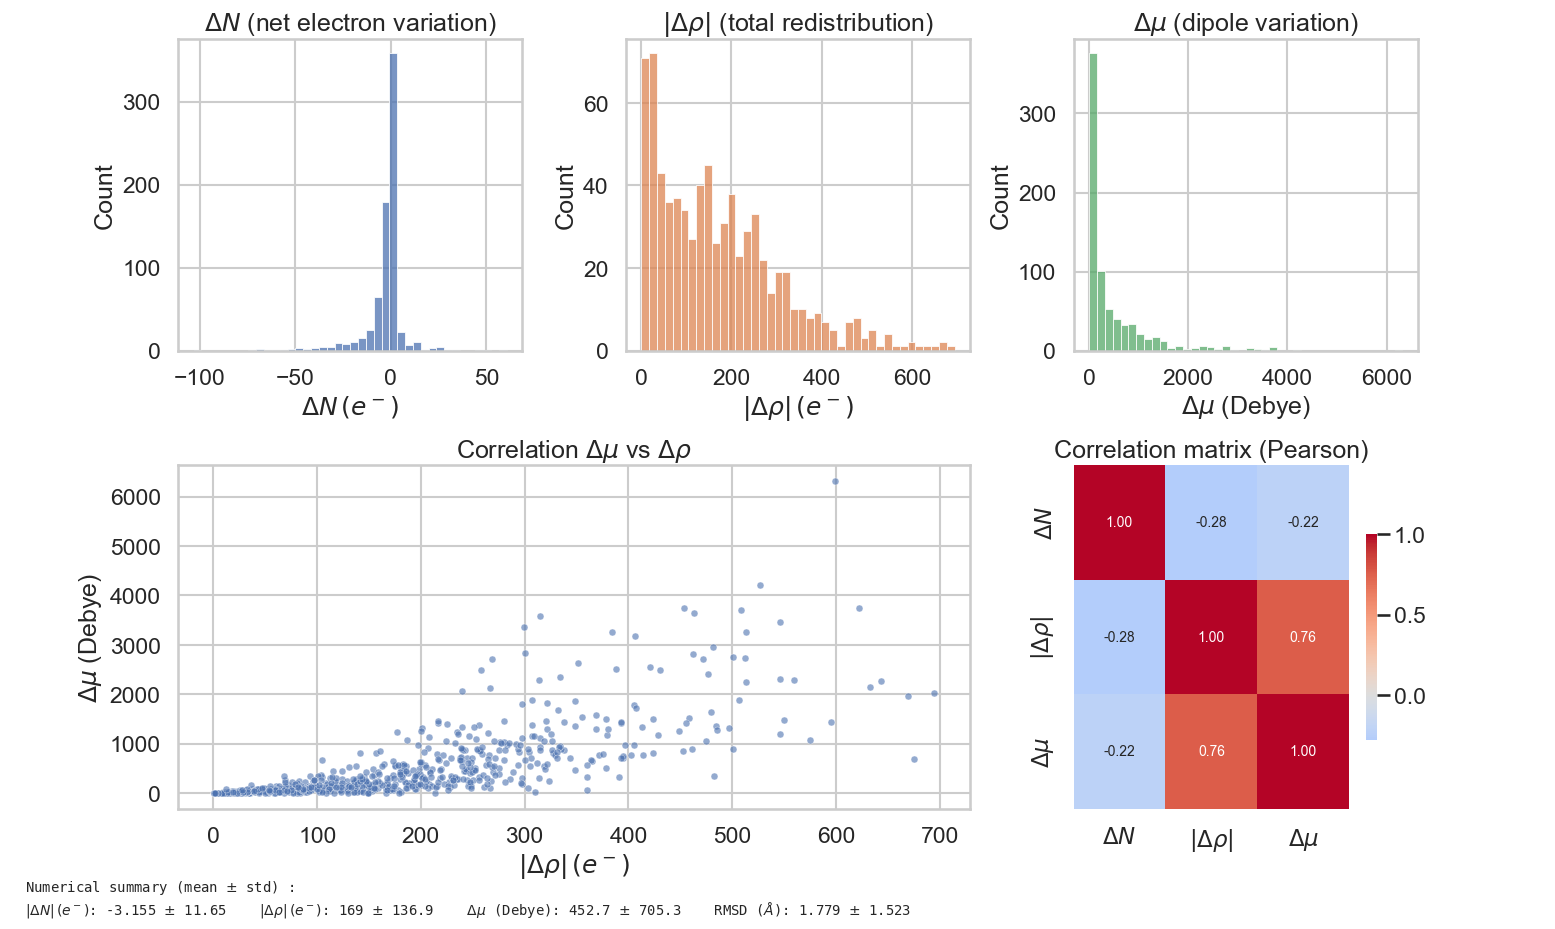

In [65]:
# -------------------------
# Génération d'une figure unique représentative
# -------------------------
df_ok = pd.read_csv(f'density_analysis_results.csv')#,index_col=0)
sns.set(style="whitegrid", context="talk")
plt.rcParams.update({"font.size": 10})

# Extraire séries
dN = df_ok["dN"].astype(float).values
dAbs = df_ok["dAbs"].astype(float).values
dMu = df_ok["dMu"].astype(float).values
rmsd = df_ok["RMSD"].astype(float).values if "RMSD" in df_ok.columns else None

# Statistiques globales
summary_stats = pd.DataFrame({
    "mean": [dN.mean(), dAbs.mean(), dMu.mean(), rmsd.mean() if rmsd is not None else np.nan],
    "std": [dN.std(ddof=1), dAbs.std(ddof=1), dMu.std(ddof=1), rmsd.std(ddof=1) if rmsd is not None else np.nan],
    "min": [dN.min(), dAbs.min(), dMu.min(), rmsd.min() if rmsd is not None else np.nan],
    "max": [dN.max(), dAbs.max(), dMu.max(), rmsd.max() if rmsd is not None else np.nan],
}, index=[r"$|\Delta N|\, (e^-)$", r"$|\Delta\rho|\, (e^-)$", r"$\Delta\mu$ (Debye)", r"RMSD ($\AA$)"])

# Figure composite : 1ère rangée = 3 histogrammes ; 2ème rangée gauche = scatter dMu vs dAbs ; droite = heatmap corrélation + résumé texte
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1], hspace=0.35, wspace=0.3)

# Hist ΔN
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(dN, bins=40, kde=False, ax=ax1, color="C0")
ax1.set_title(r"$\Delta N$ (net electron variation)") #variation nette d'électrons
ax1.set_xlabel(r"$\Delta N\, (e^-)$")

# Hist |Δρ|
ax2 = fig.add_subplot(gs[0, 1])
sns.histplot(dAbs, bins=40, kde=False, ax=ax2, color="C1")
ax2.set_title(r"$|\Delta\rho|$ (total redistribution)") #redistribution totale
ax2.set_xlabel(r"$|\Delta\rho|\, (e^-)$")

# Hist Δμ
ax3 = fig.add_subplot(gs[0, 2])
sns.histplot(dMu, bins=40, kde=False, ax=ax3, color="C2")
ax3.set_title(r"$\Delta\mu$ (dipole variation)")
ax3.set_xlabel(r"$\Delta\mu$ (Debye)")

# Scatter Δμ vs |Δρ|
ax4 = fig.add_subplot(gs[1, 0:2])
sns.scatterplot(x=dAbs, y=dMu, ax=ax4, alpha=0.6, s=25)
ax4.set_xlabel(r"$|\Delta\rho|\, (e^-)$")
ax4.set_ylabel(r"$\Delta\mu$ (Debye)")
ax4.set_title(r"Correlation $\Delta\mu$ vs $\Delta\rho$")

# Heatmap de corrélation + encadré résumé
ax5 = fig.add_subplot(gs[1, 2])
corr_df = pd.DataFrame({r"$\Delta N$": dN, r"$|\Delta\rho|$": dAbs, r"$\Delta\mu$": dMu})
corr = corr_df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax5,
            cbar_kws={"shrink": 0.6})
ax5.set_title("Correlation matrix (Pearson)") #Matrice de corrélation

# Ajouter résumé numérique sous forme de texte
text_ax = fig.add_axes([0.02, 0.02, 0.96, 0.0])  # zone en bas pour le texte résumé
text_ax.axis("off")
txt = r"Numerical summary (mean $\pm$ std) :"+"\n" #Résumé numérique
for idx in summary_stats.index:
    mean = summary_stats.loc[idx, "mean"]
    std = summary_stats.loc[idx, "std"]
    txt += r"{}: {:.4g} $\pm$ {:.4g}    ".format(idx, mean, std)
text_ax.text(0.01, 0.5, txt, fontsize=10, va="center", ha="left", family="monospace")

# Sauvegarde et affichage
outfig = "densityGlobalSummaryArticle.pgf"
fig.savefig(outfig, dpi=300, bbox_inches="tight")
print(f"Figure globale sauvegardée : {outfig}")

# Sauvegarder aussi les stats détaillées
summary_stats.to_csv("density_summary_stats.csv")
print("Fichier CSV des stats : density_summary_stats.csv")
plt.show()

In [77]:
747/5

149.4

# Analyse torsional angle

Voir le répertoire `ForTorsionalAngle`. L'analyse a été faite grâce à clade.ai via `qodo` $\Delta\delta i_{solv}  (\unit{\degree})$

In [172]:
TorsAng = pd.read_csv(f'ForTorsionalAngle/Torsional_Angles.csv',index_col=0)
TorsAng

,Donor type,Acceptor type,$\delta i$ ($\unit{\degree} $ in vacuum),$\delta i$ ($\unit{\degree} $ in toluene solvant)
Molecule,,,,
-ph-pCzAnBzt,N-phenylcarbazole,benzonitrile,155.887955,141.038359
11-AcBPdCN,triphenylamine,benzonitrile,-4.963751,5.322641
11-AcBPdCN,triphenylamine,benzonitrile,177.302387,-176.625977
11-AcBPdCN,triphenylamine,pyrazine,-5.144704,5.134685
12AcCz-PM,N-phenylcarbazole,pyrimidine,-101.108882,-153.279851
...,...,...,...,...
β-DI-DBP,N-phenylcarbazole,pyrazine,178.976036,178.819816
β-DI-DBP,N-phenylcarbazole,pyrazine,88.517596,87.500845
δ-2CbPN,desc\_multi\_amine\_donor,benzonitrile,-178.236316,-177.838199


In [179]:
TorsAng[r'$\Delta\delta i_{solv}  (\unit{\degree})$'] = np.abs(TorsAng[r"$\delta i$  ($\unit{\degree} $ in vacuum)"]-TorsAng[r"$\delta i$  ($\unit{\degree} $ in toluene solvant)"])

In [180]:
TorsAng

,Donor type,Acceptor type,$\delta i$ ($\unit{\degree} $ in vacuum),$\delta i$ ($\unit{\degree} $ in toluene solvant),$\Delta\delta i_{solv} (\unit{\degree})$
Molecule,,,,,
-ph-pCzAnBzt,N-phenylcarbazole,benzonitrile,155.887955,141.038359,14.849596
11-AcBPdCN,triphenylamine,benzonitrile,-4.963751,5.322641,10.286392
11-AcBPdCN,triphenylamine,benzonitrile,177.302387,-176.625977,353.928364
11-AcBPdCN,triphenylamine,pyrazine,-5.144704,5.134685,10.279389
12AcCz-PM,N-phenylcarbazole,pyrimidine,-101.108882,-153.279851,52.170969
...,...,...,...,...,...
β-DI-DBP,N-phenylcarbazole,pyrazine,178.976036,178.819816,0.156220
β-DI-DBP,N-phenylcarbazole,pyrazine,88.517596,87.500845,1.016751
δ-2CbPN,desc\_multi\_amine\_donor,benzonitrile,-178.236316,-177.838199,0.398117


In [182]:
#TorsAng.to_csv(f'ForTorsionalAngle/Torsional_AnglesComplete.csv')

In [187]:
TorsAngC = pd.read_csv(f'ForTorsionalAngle/Torsional_AnglesComplete.csv',index_col=0)
TorsAngC

,Donor type,Acceptor type,$\delta i$ ($\unit{\degree} $ in vacuum),$\delta i$ ($\unit{\degree} $ in toluene solvant),$\Delta\delta i_{solv} (\unit{\degree})$
Molecule,,,,,
-ph-pCzAnBzt,N-phenylcarbazole,benzonitrile,155.887955,141.038359,14.849596
11-AcBPdCN,triphenylamine,benzonitrile,-4.963751,5.322641,10.286392
11-AcBPdCN,triphenylamine,benzonitrile,177.302387,-176.625977,353.928364
11-AcBPdCN,triphenylamine,pyrazine,-5.144704,5.134685,10.279389
12AcCz-PM,N-phenylcarbazole,pyrimidine,-101.108882,-153.279851,52.170969
...,...,...,...,...,...
β-DI-DBP,N-phenylcarbazole,pyrazine,178.976036,178.819816,0.156220
β-DI-DBP,N-phenylcarbazole,pyrazine,88.517596,87.500845,1.016751
δ-2CbPN,desc\_multi\_amine\_donor,benzonitrile,-178.236316,-177.838199,0.398117


In [188]:
print(TorsAngC.to_latex(multirow = True, multicolumn = True, float_format = "%.3f"))

\begin{tabular}{lllrrr}
\toprule
 & Donor type & Acceptor type & $\delta i$  ($\unit{\degree} $ in vacuum) & $\delta i$  ($\unit{\degree} $ in toluene solvant) & $\Delta\delta i_{solv}  (\unit{\degree})$ \\
Molecule &  &  &  &  &  \\
\midrule
-ph-pCzAnBzt & N-phenylcarbazole & benzonitrile & 155.888 & 141.038 & 14.850 \\
11-AcBPdCN & triphenylamine & benzonitrile & -4.964 & 5.323 & 10.286 \\
11-AcBPdCN & triphenylamine & benzonitrile & 177.302 & -176.626 & 353.928 \\
11-AcBPdCN & triphenylamine & pyrazine & -5.145 & 5.135 & 10.279 \\
12AcCz-PM & N-phenylcarbazole & pyrimidine & -101.109 & -153.280 & 52.171 \\
12AcCz-PM & triphenylamine & pyrimidine & 35.274 & -12.261 & 47.535 \\
12BTCzTPN & N-phenylcarbazole & dicyanobenzene & 178.556 & 177.197 & 1.359 \\
12BTCzTPN & N-phenylcarbazole & dicyanobenzene & -177.947 & 179.610 & 357.557 \\
12BTCzTPN & dibenzothiophene & dicyanobenzene & 99.062 & 125.770 & 26.708 \\
12BTCzTPN & dibenzothiophene & dicyanobenzene & 168.352 & 160.399 & 7.953 \\